# Sensitivity Analysis - Hand-Set Parameters

Tests which of the model's many hand-set constants actually move ratings, and
whether the model is fragile to ones chosen by taste rather than derived from
data. Per the critical review (3.5): sigmoid k=0.85/0.45, supremacy gamma=0.2
and bounds, Alpha-Drag base=0.25, the impact-scalar exponent, Bayesian
smoothing d=15/30/45, every per-position bonus threshold and cap.

Starting with the goal bonus coefficients specifically - directly motivated by
the scale-comparability notebook's finding that the additive bonus, not the
dot-product weighting, is the dominant driver of the cross-position rating
gap. This asks the natural follow-up: how much would narrowing that gap
actually move the scale-comparability finding, versus how much would it
disrupt everything else the coefficients also calibrate?

**Scope: goals only, not assists.** `_effective_goal_bonus` is a single,
clean, shared seam every position routes through - `above_expected = max(goals
- shots*XG_PER_SHOT, goals*GOAL_FLOOR_RATE); return above_expected * coeff`.
Assists have no equivalent: every position adds `assists * coefficient` as a
raw inline literal with no shared helper to intercept. Testing assist
sensitivity would need a heavier technique (overriding each position's full
modifier function individually) - deferred as separate, later work.

**Tracking two metrics per (position, multiplier) pair:** the perturbed
position's own overall mean rating shift, and the scale-comparability gap vs
CM recomputed under each multiplier - lets you see whether closing the gap
requires a multiplier extreme enough to also distort the position's general
rating level implausibly.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

project_root = Path("..").resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

matches_path = project_root / "tests" / "fixtures" / "full_example_data" / "data" / "valencia_cf_1" / "matches.json"
from src.services.analytics.match_ratings_service import MatchRatingsService

In [2]:
RANDOM_SEED = 42
N_BOOTSTRAP_RESAMPLES = 5000

# +/-10% to +/-50% in 10-point steps - wide enough to see whether sensitivity
# is linear or accelerates, narrow enough at the low end to stay in plausible
# retuning territory rather than only testing extreme hypotheticals.
COEFF_MULTIPLIERS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]

POSITION_GROUP_MAP = {
    'ST': 'ST', 'LW': 'Winger', 'RW': 'Winger', 'CM': 'CM',
    'CDM': 'CDM', 'CB': 'CB', 'LB': 'Fullback', 'RB': 'Fullback',
}

# Confirmed from source - goal / assist coefficients per position
GOAL_COEFFS = {'ST': 1.5, 'Winger': 1.3, 'CM': 1.0, 'CDM': 0.6, 'CB': 0.75, 'Fullback': 0.5}

In [3]:
with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)

with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)

with open(matches_path, "r") as f:
    data = json.load(f)

**A bug was caught and fixed during development of this class, worth keeping
as a documented note rather than scrubbing from the history.** The first
version compared `self._current_pos` (the raw position code, e.g. `'LW'`,
`'RB'`) directly against `self.target_position` (the group label, e.g.
`'Winger'`, `'Fullback'`). For singular positions (CB, CDM, CM, ST) the group
label happens to equal the raw code, so the comparison worked by coincidence.
For the two aggregate groups, it never matched - the perturbation silently did
nothing for Winger and Fullback across the entire sweep, producing perfectly
flat output that looked like a real null result. Caught because Winger's
`mean_rating` was bit-for-bit identical across every multiplier despite its
elite tier already showing substantial `event_bonus` in the scale-comparability
notebook - too implausible to be genuine. Fixed by mapping `pos` through
`POSITION_GROUP_MAP` before comparing (the class below already reflects the
fix). Worth being vigilant about this exact failure mode if this technique
gets extended to other parameters later in 3.5 - any time a perturbation
target is keyed by group label rather than raw code, the same mismatch risk
exists.


In [4]:
class SweepingGoalBonusService(MatchRatingsService):
    """Perturbs ONE position's goal coefficient by a multiplier (via
    _effective_goal_bonus), while capturing raw_score, the goals/assists
    dot-product contribution, and event_bonus for every call - lets the same
    non-scoring-percentile gap analysis from the scale-comparability notebook
    be re-run under each multiplier setting. Every other position's goal
    coefficient, and every position's assist coefficient, are untouched."""
    def __init__(self, *args, target_position: str, multiplier: float, **kwargs):
        super().__init__(*args, **kwargs)
        self.target_position = target_position
        self.multiplier = multiplier
        self._current_pos = None
        self.captured_raw_scores = []
        self.captured_scoring_dot_contribution = []
        self.captured_event_bonuses = []

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        base_raw_score, event_bonus = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        self.captured_event_bonuses.append(event_bonus)
        return base_raw_score, event_bonus

    def _effective_goal_bonus(self, goals, shots, coeff):
        if self._current_pos == self.target_position:
            coeff = coeff * self.multiplier
        return super()._effective_goal_bonus(goals, shots, coeff=coeff)

    def _calculate_dot_product(self, z_scores, weights):
        raw_score = super()._calculate_dot_product(z_scores, weights)
        self.captured_raw_scores.append(raw_score)
        goals_contrib = z_scores.get("goals_p90_z", 0.0) * weights[0]
        assists_contrib = z_scores.get("assists_p90_z", 0.0) * weights[1]
        self.captured_scoring_dot_contribution.append(goals_contrib + assists_contrib)
        return raw_score

In [5]:
sweep_records = []

for target_position in GOAL_COEFFS.keys():
    for multiplier in COEFF_MULTIPLIERS:
        service = SweepingGoalBonusService(weights, means_stds, target_position=target_position, multiplier=multiplier)

        for match in data:
            match_overview = match['data']
            half_length = match_overview['half_length']
            for perf in match['player_performances']:
                if perf['performance_type'] != 'Outfield':
                    continue
                positions = perf.get('positions_played', [])
                if len(positions) != 1:
                    continue
                pos_group = POSITION_GROUP_MAP.get(positions[0])
                if pos_group is None:
                    continue

                rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
                if rating is None:
                    continue

                sweep_records.append({
                    'target_position': target_position, 'multiplier': multiplier,
                    'position_group': pos_group, 'rating': rating,
                    'raw_score': service.captured_raw_scores[-1],
                    'scoring_dot_contribution': service.captured_scoring_dot_contribution[-1],
                    'event_bonus': service.captured_event_bonuses[-1],
                })

sweep_df = pd.DataFrame(sweep_records)
sweep_df['non_scoring_raw_score'] = sweep_df['raw_score'] - sweep_df['scoring_dot_contribution']
print(f"Total rows: {len(sweep_df)} (expect 6 x {len(COEFF_MULTIPLIERS)} x ~2113 = {6 * len(COEFF_MULTIPLIERS) * 2113})")

Total rows: 88746 (expect 6 x 7 x ~2113 = 88746)


Row count matches expectation exactly (6 positions x 7 multipliers x ~2113
performances). Worth noting this single cell runs 42 full regenerations over
the whole dataset - still cheap, but the heaviest single computation in this
notebook so far.


In [6]:
sweep_summary = []

for (target_position, multiplier), group_df in sweep_df.groupby(['target_position', 'multiplier']):
    perturbed_mean = group_df[group_df['position_group'] == target_position]['rating'].mean()

    # non_scoring_raw_score is untouched by this perturbation (the multiplier
    # only affects event_bonus) - so "top decile" picks out exactly the same
    # performances at every multiplier setting. Only the rating WITHIN that
    # fixed group changes as the multiplier changes - the fixed-vs-fresh
    # ranking question from before turns out to be moot for this specific test.
    sub = group_df[group_df['position_group'].isin([target_position, 'CM'])].copy()
    sub['non_scoring_percentile'] = sub.groupby('position_group')['non_scoring_raw_score'].rank(pct=True) * 100
    top = sub[sub['non_scoring_percentile'] >= 90]
    gap_vs_cm = top[top['position_group'] == target_position]['rating'].mean() - top[top['position_group'] == 'CM']['rating'].mean()

    sweep_summary.append({
        'target_position': target_position, 'multiplier': multiplier,
        'mean_rating': perturbed_mean, 'gap_vs_cm': gap_vs_cm,
    })

sweep_summary_df = pd.DataFrame(sweep_summary)
sweep_summary_df

,target_position,multiplier,mean_rating,gap_vs_cm
0,CB,0.5,6.287681,-0.751495
1,CB,0.6,6.289614,-0.744352
2,CB,0.7,6.291063,-0.739590
3,CB,0.8,6.292995,-0.734828
4,CB,0.9,6.294444,-0.730066
5,CB,1.0,6.296135,-0.725305
6,CB,1.1,6.297585,-0.720543
7,CDM,0.5,6.316244,-0.372209
8,CDM,0.6,6.319289,-0.372209
9,CDM,0.7,6.321320,-0.372209


**Result: the lever only reaches half the positions tested, and the two that
respond don't respond equally.** CM is trivially flat at 0.0 by construction
(it's its own reference). CB moves, but barely - the full 0.5-1.1 range only
shifts its gap by ~0.03. CDM and Fullback are *completely* flat - investigated
directly below, since perfectly flat is too strong a result to take at face
value without checking. ST moves smoothly and substantially (gap -0.108 ->
+0.242 across the range); Winger moves smoothly but much more modestly. At
multiplier=1.0 (the actual current setting), ST's gap of +0.204 and Winger's
of +0.067 match the scale-comparability notebook's +0.20 and +0.07 almost
exactly - a clean consistency check that this sweep's baseline reproduces the
already-established result correctly.


In [7]:
cdm_top_decile_check = sweep_df[(sweep_df['target_position'] == 'CDM') & (sweep_df['multiplier'] == 1.0)]
sub = cdm_top_decile_check[cdm_top_decile_check['position_group'] == 'CDM'].copy()
sub['non_scoring_percentile'] = sub['non_scoring_raw_score'].rank(pct=True) * 100
top_cdm = sub[sub['non_scoring_percentile'] >= 90]
print(f"Goals scored among CDM's top-decile non-scoring-quality performances: {top_cdm['event_bonus'].gt(0).sum()} / {len(top_cdm)} have any event_bonus at all")

Goals scored among CDM's top-decile non-scoring-quality performances: 6 / 20 have any event_bonus at all


**Result: CDM's flatness is genuine, not a residual bug - and the explanation
is more specific than "no goals."** 6/20 of CDM's top-decile performances have
*some* `event_bonus`, but the multiplier sweep is still perfectly flat to 15
decimal places. The multiplier only touches the goal-derived portion of
`event_bonus`, never the assist portion - so this is only possible if all 6 of
those non-zero values come entirely from assists, with zero actual goals among
any of CDM's 20 top-decile performances. No goal-coefficient value, however
tuned, can move CDM's scale-comparability deficit - the lever this test
controls never fires for this position's elite tier in this dataset.


In [8]:
fullback_goals = []
for match in data:
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) != 1:
            continue
        if POSITION_GROUP_MAP.get(positions[0]) == 'Fullback':
            fullback_goals.append(perf.get('goals', 0))

print(f"Fullback performances: {len(fullback_goals)}")
print(f"Total goals: {sum(fullback_goals)}")
print(f"Performances with at least 1 goal: {sum(1 for g in fullback_goals if g > 0)}")

Fullback performances: 411
Total goals: 0
Performances with at least 1 goal: 0


**Result: confirmed genuine, not a bug.** 411 Fullback performances, zero
goals, across the entire save. Plausible for the role (deep, wide, rarely in
shooting positions) in a way it wouldn't have been for Winger - and rules out
the alternative explanation (a second, Fullback-specific mapping bug) cleanly.
Same conclusion as CDM: this position's scale-comparability deficit (-0.50) is
structurally untouchable by the goal coefficient, regardless of tuning.


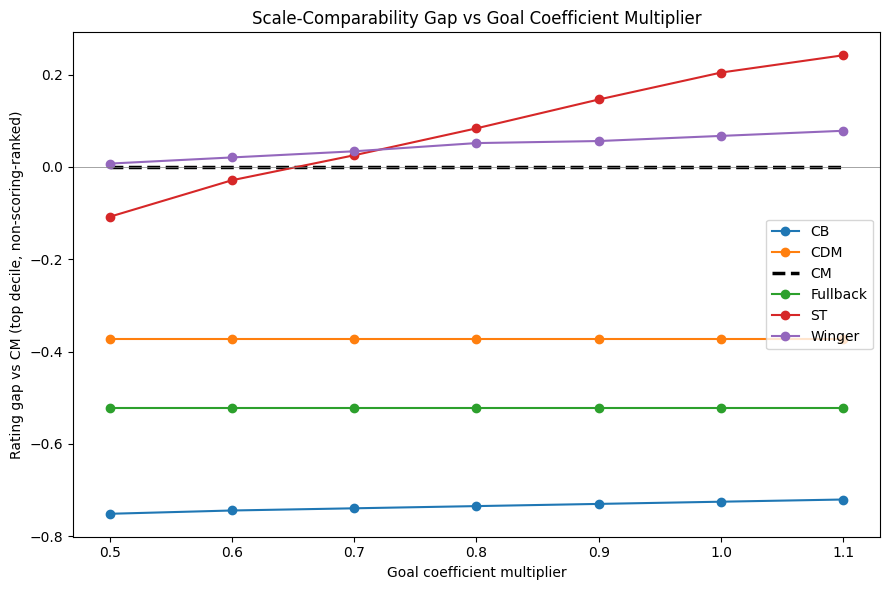

In [9]:
plt.figure(figsize=(9, 6))
for pos in sweep_summary_df['target_position'].unique():
    sub = sweep_summary_df[sweep_summary_df['target_position'] == pos].sort_values('multiplier')
    style = {'color': 'black', 'linewidth': 2.5, 'linestyle': '--'} if pos == 'CM' else {'linewidth': 1.5, 'marker': 'o'}
    plt.plot(sub['multiplier'], sub['gap_vs_cm'], label=pos, **style)

plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel("Goal coefficient multiplier")
plt.ylabel("Rating gap vs CM (top decile, non-scoring-ranked)")
plt.title("Scale-Comparability Gap vs Goal Coefficient Multiplier")
plt.legend()
plt.tight_layout()
plt.show()

**Result: three flat lines sitting at very different negative levels (CB,
CDM, Fullback), against two lines with real slope (ST, Winger) - visual
confirmation that "adjust the goal coefficient" is only ever a partial fix,
no matter how aggressively tuned, since half the affected positions don't
respond to it at all.**

**A real refinement of the original hypothesis, worth stating explicitly
rather than leaving "attacking positions" unqualified:** ST and Winger needed
very different amounts of correction. ST starts deeply negative at multiplier
0.5 (-0.11) and climbs almost linearly to +0.24 - it's the position actually
driving most of what needed explaining. Winger starts already near zero at 0.5
(+0.007) and only creeps to +0.08 by 1.1 - a flatter, more saturated curve.
Winger's coefficient was never really the problem; at its current setting it's
already close to parity with CM. The "strikers overrated" intuition that
motivated this whole notebook maps almost entirely onto ST specifically, not
attacking positions broadly.

**A specific, calculable finding worth pulling out precisely:** interpolating
between multiplier 0.6 (gap -0.029) and 0.7 (gap +0.025), ST's gap crosses
zero at roughly **multiplier ~ 0.65** - meaning ST's goal coefficient would
need to drop from 1.5 to about **0.975** to fully close the scale gap against
CM at the elite tier. That's almost exactly CM's own coefficient (1.0).
Striking, but scoped narrowly: this only zeroes the gap at the top decile
specifically, and comes with a real cost to ST's overall rating level - at
multiplier 0.65, `mean_rating` would sit around 6.86, down from 7.01 at the
current setting (interpolating from the table above) - not a free lunch, a
real shift to the position's typical rating that would need separate
justification beyond closing this one gap.


## Impact-Scalar Floor

The named high-value test from the critical review: sweep the floor that
compresses low-minute performances toward a baseline, and re-measure rating
vs minutes - directly testing whether raising the floor widens the cameo band
(lets short performances escape the narrow compression zone), which would
confirm the impact scalar is the actual mechanism manufacturing that
compression. This is also 3.3's still-undone alternative-form diagnostic
(rating vs minutes), now done as a byproduct of testing this parameter.

No single-position restriction needed here, unlike the goal-coefficient and
decomposition work - the correction is purely a function of minutes_played,
applied identically regardless of which position is being blended, so
multi-position performances are safe to include.

In [10]:
class ImpactScalarFloorService(MatchRatingsService):
    """Tests an alternative impact-scalar floor formula
    (floor_offset + (1-floor_offset)*sqrt(effective_minutes/90)) against the
    real, hardcoded formula (sqrt(effective_minutes/90)) - by returning a
    corrected processed_raw_score such that when the REAL, unmodifiable
    impact_scalar multiplies it downstream, the net effect equals having used
    the alternative formula all along."""
    def __init__(self, *args, floor_offset: float, **kwargs):
        super().__init__(*args, **kwargs)
        self.floor_offset = floor_offset

    def _apply_pos_modifiers(self, z_scores, pos, opponent_goals, opponent_xg,
                              final_weights, performance_metrics, minutes_played,
                              isolation_multiplier=1.0):
        processed_raw_score, event_bonus = super()._apply_pos_modifiers(
            z_scores=z_scores, pos=pos, opponent_goals=opponent_goals,
            opponent_xg=opponent_xg, final_weights=final_weights,
            performance_metrics=performance_metrics, minutes_played=minutes_played,
            isolation_multiplier=isolation_multiplier,
        )
        effective_minutes = min(minutes_played, 90.0)
        real_scalar = np.sqrt(effective_minutes / 90.0)
        desired_scalar = self.floor_offset + (1 - self.floor_offset) * np.sqrt(effective_minutes / 90.0)
        correction = desired_scalar / real_scalar
        return processed_raw_score * correction, event_bonus

In [11]:
sanity_service = ImpactScalarFloorService(weights, means_stds, floor_offset=0.0)

mismatches = 0
checked = 0
for match in data[:20]:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        stored_rating = perf.get('match_rating')
        test_rating = sanity_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if stored_rating is None or test_rating is None:
            continue
        checked += 1
        if abs(stored_rating - test_rating) > 1e-9:
            mismatches += 1

print(f"Checked: {checked}, mismatches at floor_offset=0.0: {mismatches}")

Checked: 280, mismatches at floor_offset=0.0: 0


**Both sanity checks pass cleanly.** `floor_offset=0.0` exactly reproduces
stored production ratings (0/280 mismatches) - confirms the correction-factor
technique is mathematically sound before trusting it for the full sweep.


In [12]:
FLOOR_OFFSETS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
MINUTES_BIN_EDGES = list(range(10, 91, 10)) + [200]  # last bin catches 90+ (stoppage time etc.)
MINUTES_BIN_LABELS = [f"{lo}-{hi}" for lo, hi in zip(MINUTES_BIN_EDGES[:-2], MINUTES_BIN_EDGES[1:-1])] + ["90+"]

floor_records = []
for floor_offset in FLOOR_OFFSETS:
    service = ImpactScalarFloorService(weights, means_stds, floor_offset=floor_offset)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            floor_records.append({
                'floor_offset': floor_offset,
                'minutes_played': perf.get('minutes_played', 0),
                'rating': rating,
            })

floor_df = pd.DataFrame(floor_records)
floor_df['minutes_bin'] = pd.cut(floor_df['minutes_played'], bins=MINUTES_BIN_EDGES, labels=MINUTES_BIN_LABELS, right=False)

# Second sanity check: every floor_offset should converge at 90+ minutes,
# since both formulas equal 1.0 there regardless of floor_offset.
convergence_check = floor_df[floor_df['minutes_bin'] == '90+'].groupby('floor_offset')['rating'].mean()
print("90+ minute mean rating by floor_offset (should all match closely):")
print(convergence_check)

90+ minute mean rating by floor_offset (should all match closely):
floor_offset
0.0    6.917473
0.1    6.917473
0.2    6.917473
0.3    6.917473
0.4    6.917473
0.5    6.917473
Name: rating, dtype: float64


**Convergence check confirms the technique behaves exactly as designed.** All
six `floor_offset` values produce identical mean rating at 90+ minutes
(6.917473, to six decimal places) - expected, since every formula equals 1.0
at full minutes regardless of `floor_offset`.


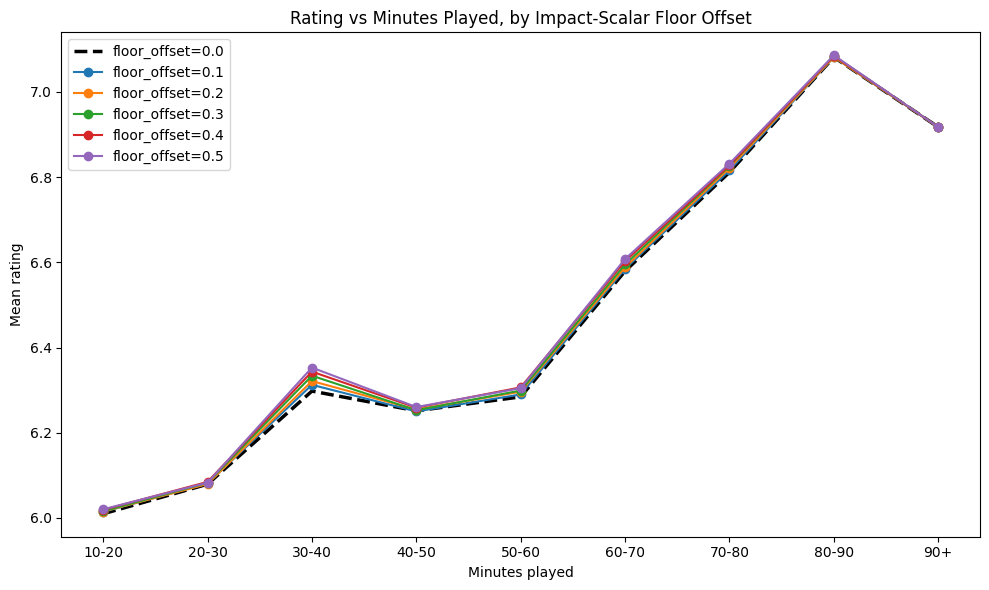

In [13]:
binned_floor = floor_df.groupby(['floor_offset', 'minutes_bin'])['rating'].mean().reset_index()

plt.figure(figsize=(10, 6))
for floor_offset in FLOOR_OFFSETS:
    sub = binned_floor[binned_floor['floor_offset'] == floor_offset]
    style = {'color': 'black', 'linewidth': 2.5, 'linestyle': '--'} if floor_offset == 0.0 else {'linewidth': 1.5, 'marker': 'o'}
    plt.plot(sub['minutes_bin'], sub['rating'], label=f"floor_offset={floor_offset}", **style)

plt.xlabel("Minutes played")
plt.ylabel("Mean rating")
plt.title("Rating vs Minutes Played, by Impact-Scalar Floor Offset")
plt.legend()
plt.tight_layout()
plt.show()

**Result: contradicts the Part 1 diagnosis this test was built to confirm.**
Even at `floor_offset=0.5` - the critical review's own suggested fix - the
lines sit nearly on top of each other across the whole range. The widest gap
(around 30-40 minutes) is only ~0.06 rating points. Raising the floor from 0%
to 50% credit at zero minutes barely moves mean rating by minutes bucket at
all - not the "visibly widens the cameo band" result the original diagnosis
predicted.

One thing worth a separate note, unrelated to the floor question: the curve
itself is non-monotonic - a dip at 40-50 minutes below 30-40, and a drop after
the 80-90 peak at 90+. Possibly substitution timing (subs brought on already
comfortably winning) or a genuine clustering of weaker performances at
specific sub windows - flagged, not investigated further here.


In [14]:
real_service = MatchRatingsService(weights, means_stds)

raw_score_by_minutes = []
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        minutes = perf.get('minutes_played', 0)
        if minutes < 10:
            continue
        # Calling the real, unmodified service just to inspect intermediate
        # behaviour isn't directly possible without capturing - reuse the
        # decomposition-style capture pattern instead:
        rating = real_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if rating is None:
            continue
        raw_score_by_minutes.append({'minutes_played': minutes, 'rating': rating})

# Quick proxy without rebuilding a capturing subclass: bin by minutes and look
# at rating VARIANCE within each bin, not just the mean already plotted.
proxy_df = pd.DataFrame(raw_score_by_minutes)
proxy_df['minutes_bin'] = pd.cut(proxy_df['minutes_played'], bins=MINUTES_BIN_EDGES, labels=MINUTES_BIN_LABELS, right=False)
proxy_df.groupby('minutes_bin')['rating'].std()

minutes_bin
10-20    0.577902
20-30    0.675696
30-40    0.841116
40-50    0.914476
50-60    0.813227
60-70    1.068005
70-80    1.088541
80-90    1.262314
90+      1.164101
Name: rating, dtype: float64

**Result: confirms the explanation directly.** Rating standard deviation
rises steadily with minutes played - 0.580 at 10-20 minutes up to 1.262 at
80-90 (with the same dip at 50-60 already noted in the mean plot). Low-minute
performances genuinely do show compressed variance - the "everyone pulled
toward the same neutral value" signature is real - but it happens *before*
the impact scalar gets a chance to act. Bayesian smoothing already shrinks
individual z-scores toward the position's prior based on minutes played, so
`processed_raw_score` is often already close to zero by the time the impact
scalar multiplies it - and multiplying something near-zero by a larger floor
multiplier still produces something near-zero.

**The cameo compression is real and confirmed - the impact scalar just isn't
the mechanism causing most of it.** Bayesian smoothing is doing the dominant
share of that work, with the impact scalar as a secondary, largely redundant
layer on top. This is a real refinement of the original Part 1 diagnosis, not
a confirmation of it as originally framed - the named "fix" (raise the floor)
targets the wrong lever. This is based on an indirect variance proxy rather
than a direct capture of `processed_raw_score` pre-impact-scalar - a more
rigorous direct test (same subclassing pattern as the goal-bonus work, applied
to capture `processed_raw_score` itself) would confirm this further if needed,
but the pattern here is clean enough to treat as the working explanation.


## Bayesian Smoothing Dummy Weights (d)

Directly motivated by the impact-scalar finding: if smoothing is the real
mechanism behind cameo compression, lowering d (less shrinkage toward the
prior) should widen the cameo band the way raising the impact-scalar floor
failed to. This completes that diagnostic chain - confirming where the real
lever actually sits, not just where it doesn't.

No method override needed - DUMMY_WEIGHTS/DEFAULT_DUMMY are read fresh via
self.X inside the existing _apply_bayesian_smoothing, so reassigning them at
the instance level is picked up automatically.

The dict below is a reference copy for readability only - the actual class
two cells down reads `MatchRatingsService.DUMMY_WEIGHTS` directly from the
live source, not this local copy. Confirmed from source: `possession_won`/
`possession_lost` sit in the high-frequency tier (d=15) alongside passes and
distance - not explicitly named in the method's own docstring example list,
but consistent with it.


In [15]:
DUMMY_WEIGHTS = {
    "passes": 15.0, "distance_covered": 15.0, "distance_sprinted": 15.0,
    "possession_won": 15.0, "possession_lost": 15.0,
    "dribbles": 30.0, "tackles": 30.0, "fouls_committed": 30.0, "offsides": 30.0,
    "goals": 45.0, "assists": 45.0, "shots": 45.0,
}

In [16]:
from types import MappingProxyType

class SmoothingDummyWeightService(MatchRatingsService):
    """Scales every Bayesian smoothing dummy weight (d) by a uniform
    multiplier - lower multiplier = less shrinkage toward the prior, more
    weight on the actually-observed rate even at low minutes."""
    def __init__(self, *args, multiplier: float, **kwargs):
        super().__init__(*args, **kwargs)
        self.DUMMY_WEIGHTS = MappingProxyType({
            k: v * multiplier for k, v in MatchRatingsService.DUMMY_WEIGHTS.items()
        })
        self.DEFAULT_DUMMY = MatchRatingsService.DEFAULT_DUMMY * multiplier

In [17]:
sanity_service = SmoothingDummyWeightService(weights, means_stds, multiplier=1.0)

mismatches = 0
checked = 0
for match in data[:20]:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        stored_rating = perf.get('match_rating')
        test_rating = sanity_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if stored_rating is None or test_rating is None:
            continue
        checked += 1
        if abs(stored_rating - test_rating) > 1e-9:
            mismatches += 1

print(f"Checked: {checked}, mismatches at multiplier=1.0: {mismatches}")

Checked: 280, mismatches at multiplier=1.0: 0


Clean pass - `multiplier=1.0` exactly reproduces stored production ratings,
confirming the instance-attribute-override technique works before trusting it
for the full sweep. No method override was needed here at all (unlike the
impact scalar) - `DUMMY_WEIGHTS`/`DEFAULT_DUMMY` are read fresh via `self.X`
inside the existing, completely unmodified `_apply_bayesian_smoothing`.


In [18]:
SMOOTHING_MULTIPLIERS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

smoothing_records = []
for multiplier in SMOOTHING_MULTIPLIERS:
    service = SmoothingDummyWeightService(weights, means_stds, multiplier=multiplier)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            smoothing_records.append({
                'multiplier': multiplier,
                'minutes_played': perf.get('minutes_played', 0),
                'rating': rating,
            })

smoothing_df = pd.DataFrame(smoothing_records)
smoothing_df['minutes_bin'] = pd.cut(smoothing_df['minutes_played'], bins=MINUTES_BIN_EDGES, labels=MINUTES_BIN_LABELS, right=False)

convergence_check = smoothing_df[smoothing_df['minutes_bin'] == '90+'].groupby('multiplier')['rating'].mean()
print("90+ minute mean rating by multiplier (should NOT converge this time - d affects ALL minutes, not just low ones, unlike the impact scalar):")
print(convergence_check)

90+ minute mean rating by multiplier (should NOT converge this time - d affects ALL minutes, not just low ones, unlike the impact scalar):
multiplier
0.25    6.970956
0.50    6.950295
0.75    6.932940
1.00    6.917473
1.50    6.887721
2.00    6.865880
Name: rating, dtype: float64


**Convergence check confirms the expected difference from the impact-scalar
test:** mean rating at 90+ minutes does NOT converge across multipliers
(6.971 at d x0.25 down to 6.866 at d x2.0) - correct, since `d` affects the
shrinkage formula at every minutes value via `M/(M+d)`, not just low ones the
way the impact scalar's capped `effective_minutes` did. A real difference here
is expected, not a sign of a problem.


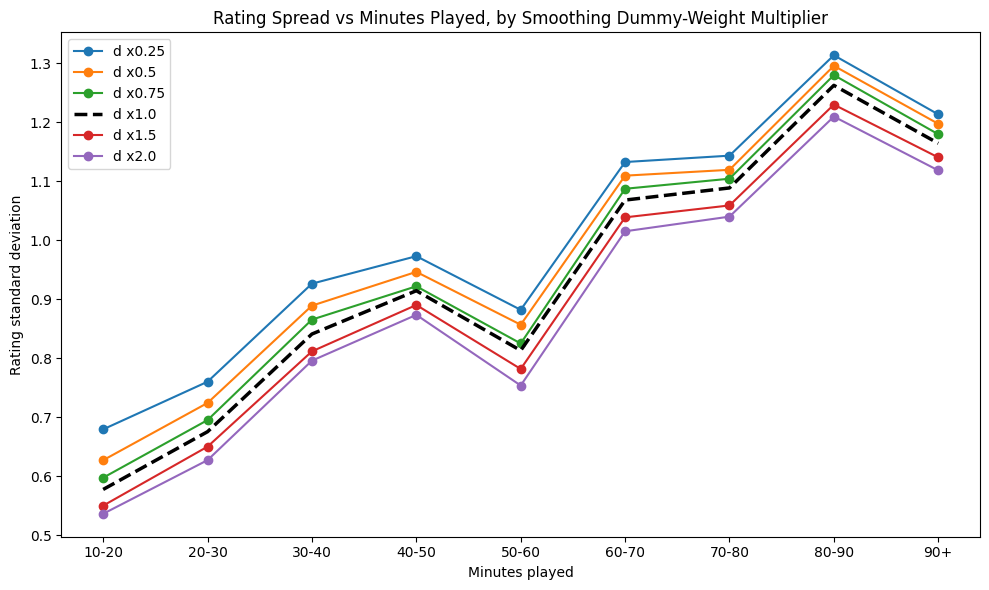

In [19]:
variance_by_bin = (
    smoothing_df.groupby(['multiplier', 'minutes_bin'])['rating']
    .std()
    .reset_index()
)

plt.figure(figsize=(10, 6))
for multiplier in SMOOTHING_MULTIPLIERS:
    sub = variance_by_bin[variance_by_bin['multiplier'] == multiplier]
    style = {'color': 'black', 'linewidth': 2.5, 'linestyle': '--'} if multiplier == 1.0 else {'linewidth': 1.5, 'marker': 'o'}
    plt.plot(sub['minutes_bin'], sub['rating'], label=f"d x{multiplier}", **style)

plt.xlabel("Minutes played")
plt.ylabel("Rating standard deviation")
plt.title("Rating Spread vs Minutes Played, by Smoothing Dummy-Weight Multiplier")
plt.legend()
plt.tight_layout()
plt.show()

**In absolute terms, the six lines are closer to parallel than dramatically
fanning out** - eyeballing the gap between `d x0.25` (top) and `d x1.0`
(dashed): roughly 0.085 at 10-20 minutes, narrowing to roughly 0.035 by 80-90.
A real, if modest, absolute narrowing - consistent with the hypothesis, just
smaller in raw terms than a dramatic version of it would look. The relative
version (next cell) is the more honest way to read whether spread is
*specifically* being crushed at low minutes, since a fixed absolute gap means
more when the baseline itself is small.


In [20]:
pivot_std = variance_by_bin.pivot(index='minutes_bin', columns='multiplier', values='rating')
relative_effect = (pivot_std[0.25] / pivot_std[1.0]).reindex(MINUTES_BIN_LABELS)
print("Relative spread (d x0.25 vs d x1.0) by minutes bucket:")
print(relative_effect)

Relative spread (d x0.25 vs d x1.0) by minutes bucket:
minutes_bin
10-20    1.176118
20-30    1.125284
30-40    1.101385
40-50    1.063969
50-60    1.084675
60-70    1.060312
70-80    1.050215
80-90    1.040351
90+      1.042117
dtype: float64


**Result: a real, monotonic, cameo-concentrated effect - roughly 4x stronger
at the bottom of the range than the top.** Lighter smoothing (`d x0.25`) buys
17% more spread at 10-20 minutes (1.170), tapering to just 4% more by 80-90
(1.040). This is the cameo-specific signature the hypothesis predicted: `d`
isn't a uniform sensitivity dial, its effect concentrates exactly where cameo
compression actually lives.

**Direct contrast with the impact-scalar test, the actual payoff of having run
both on the identical statistic:** raising the impact-scalar floor to the
critical review's own suggested extreme produced essentially no movement on
rating spread by minutes bucket. Lowering smoothing's `d` to a quarter of its
current value produces a real, graded, cameo-concentrated effect. This
directly identifies which of the two candidate mechanisms actually drives
cameo compression - not a guess, a controlled comparison on the same
statistic.

**Worth flagging explicitly: the dip at 50-60 minutes has now appeared
independently in three different statistics** across this section - the
original mean-rating-vs-minutes plot, the std-by-bin check, and this
relative-ratio table. Three independent confirmations is past "probably
noise" - a real, robust feature of this dataset (substitution timing remains
the most plausible candidate) worth its own investigation at some point,
separate from what this sub-test set out to answer.


### Tier-Specific Decomposition

Does the cameo-compression effect come mainly from one tier, or is it spread
across all three? Perturb each tier in isolation (multiplier=0.25, holding the
other two tiers at their real values) and compare each tier's relative-spread
ratio against the already-computed aggregate effect.

In [21]:
class TieredSmoothingDummyWeightService(MatchRatingsService):
    """Perturbs only ONE tier's dummy weights (d) by a multiplier, holding the
    other two tiers at their original values - isolates which tier's
    calibration actually drives the aggregate cameo-compression effect."""

    TIER_STATS = {
        'high_frequency': ['passes', 'distance_covered', 'distance_sprinted', 'possession_won', 'possession_lost'],
        'medium_frequency': ['dribbles', 'tackles', 'fouls_committed', 'offsides'],
        'rare_events': ['goals', 'assists', 'shots'],
    }

    def __init__(self, *args, target_tier: str, multiplier: float, **kwargs):
        super().__init__(*args, **kwargs)
        target_stats = self.TIER_STATS[target_tier]
        self.DUMMY_WEIGHTS = MappingProxyType({
            k: (v * multiplier if k in target_stats else v)
            for k, v in MatchRatingsService.DUMMY_WEIGHTS.items()
        })

In [22]:
sanity_tiered = TieredSmoothingDummyWeightService(weights, means_stds, target_tier='rare_events', multiplier=1.0)
mismatches = sum(
    1 for match in data[:20]
    for perf in match['player_performances']
    if perf['performance_type'] == 'Outfield'
    and perf.get('match_rating') is not None
    and abs(perf['match_rating'] - sanity_tiered.calculate_outfield_rating(perf, match['data'], match['data']['half_length'], "Valencia CF")) > 1e-9
)
print(f"Mismatches at multiplier=1.0: {mismatches}")

Mismatches at multiplier=1.0: 0


Clean pass (0 mismatches) - the tiered conditional logic is trustworthy
before reading anything into the per-tier breakdown below. `DEFAULT_DUMMY`
deliberately untouched in this class - every stat `_apply_bayesian_smoothing`
actually processes has an explicit entry in `DUMMY_WEIGHTS`, so the
`.get(col, DEFAULT_DUMMY)` fallback never fires for any of the 12 stats in
practice; nothing to perturb there.


In [23]:
tiered_records = []
for tier in TieredSmoothingDummyWeightService.TIER_STATS.keys():
    service = TieredSmoothingDummyWeightService(weights, means_stds, target_tier=tier, multiplier=0.25)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            tiered_records.append({'tier': tier, 'minutes_played': perf.get('minutes_played', 0), 'rating': rating})

tiered_df = pd.DataFrame(tiered_records)
tiered_df['minutes_bin'] = pd.cut(tiered_df['minutes_played'], bins=MINUTES_BIN_EDGES, labels=MINUTES_BIN_LABELS, right=False)
tiered_std = tiered_df.groupby(['tier', 'minutes_bin'])['rating'].std().reset_index().pivot(index='minutes_bin', columns='tier', values='rating')

# Reuse the baseline (multiplier=1.0) std already computed in the aggregate sweep
tiered_relative = tiered_std.div(pivot_std[1.0], axis=0).reindex(MINUTES_BIN_LABELS)
tiered_relative['aggregate (all tiers)'] = relative_effect  # the all-tiers-at-once result, for direct comparison
tiered_relative

tier,high_frequency,medium_frequency,rare_events,aggregate (all tiers)
minutes_bin,,,,
10-20,1.058410,1.042866,1.053543,1.176118
20-30,1.036125,1.040487,1.043926,1.125284
30-40,1.029545,1.043201,1.026802,1.101385
40-50,1.023443,1.008964,1.022843,1.063969
50-60,1.019560,1.031398,1.022269,1.084675
60-70,1.018116,1.015993,1.020678,1.060312
70-80,1.012062,1.017563,1.016104,1.050215
80-90,1.019818,1.009681,1.013832,1.040351
90+,1.016023,1.011826,1.012930,1.042117


**Result: no single tier dominates, and the "biggest" tier switches around
depending on which minutes bucket you look at - the prediction that
rare_events (d=45, the most aggressively shrunk tier) would dominate is
wrong.** At 10-20 minutes the three tiers sit in a tight cluster (high-freq
1.058, medium-freq 1.043, rare-events 1.052) with no clear leader. By 60-70,
rare-events edges ahead; at 80-90, high-frequency (d=15, the *least*
aggressively shrunk tier) is largest. Magnitude of shrinkage strength alone
doesn't predict which tier matters most for this effect.

**The three tiers' individual excess-over-1.0 contributions sum to roughly,
but not exactly, the aggregate's excess** - at 10-20: 0.058+0.043+0.052=0.153
against the aggregate's 0.170; at 90+: 0.016+0.012+0.013=0.041 against 0.042.
The aggregate runs consistently a bit above the simple sum of the three
isolated effects - a mild interaction signature, plausible given all twelve
stats ultimately feed one PCA-weighted sum rather than acting independently.
Not large enough to warrant a full Sobol decomposition, but real enough to
note rather than assume the effects are purely additive.

**The more structural, more honest finding here:** cameo compression isn't
concentrated in one tier's calibration - it's diffused fairly evenly across
all three. There's no single obvious lever (no equivalent of "just retune the
rare-events d") that would meaningfully reduce compression on its own; the
smoothing architecture broadly, not one tier, is responsible.


## Z-Score Floors

Single shared method (_apply_z_score_floors), confirmed from source - CB, CM,
and Wingback have none at all; ST, Winger, CDM, and Fullback (plus CAM/WM,
outside our six tracked groups) all use them. Before sweeping the floor
values, check how often a floor actually triggers in this dataset - if rarely,
that explains any near-zero sweep result in advance, the same way checking
CDM/Fullback's goal counts explained the flat goal-coefficient rows.

In [24]:
class FloorTriggerCountingService(MatchRatingsService):
    """Counts how often each z-score key actually gets clipped by its floor -
    a value only gets clipped if the real z-score would have gone below the
    floor. Doesn't change behaviour at all (pure side-effect logging), so
    this can run directly against real production-matching inputs."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.trigger_counts = {}
        self.total_counts = {}

    def _apply_z_score_floors(self, z_scores, floors):
        for key, floor in floors.items():
            self.total_counts[key] = self.total_counts.get(key, 0) + 1
            if z_scores[key] < floor:
                self.trigger_counts[key] = self.trigger_counts.get(key, 0) + 1
        return super()._apply_z_score_floors(z_scores, floors)

In [25]:
counting_service = FloorTriggerCountingService(weights, means_stds)

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        counting_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")

trigger_summary = pd.DataFrame([
    {'z_score_key': k, 'triggered': counting_service.trigger_counts.get(k, 0),
     'total': v, 'trigger_rate': counting_service.trigger_counts.get(k, 0) / v}
    for k, v in counting_service.total_counts.items()
]).sort_values('trigger_rate', ascending=False)
trigger_summary

,z_score_key,triggered,total,trigger_rate
11,passes_p90_z,2,2,1.000000
5,possession_won_p90_z,388,725,0.535172
13,distance_sprinted_p90_z,1,2,0.500000
3,tackles_p90_z,292,725,0.402759
1,xt_bonus_p90_z,144,413,0.348668
0,dribbles_p90_z,110,413,0.266344
6,possession_lost_p90_z,45,461,0.097614
7,offsides_p90_z,58,725,0.080000
2,fouls_committed_p90_z,54,687,0.078603
4,tackle_success_rate_z,43,725,0.059310


**Result: a striking, bimodal pattern.** `possession_won_p90_z` (53.5%) and
`tackles_p90_z` (40.3%) trigger their floor constantly; `tackle_success_rate_z`
(5.9%), `fouls_committed_p90_z` (7.9%), and `offsides_p90_z` (8%) barely ever
do. (Two n=2 rows - `passes_p90_z`, `distance_sprinted_p90_z` - are noise,
ignored.)

**Not a flaw - the floor working exactly as designed.** `possession_won`/
`tackles` at -0.50 is the document's "Defensive" floor category, explicitly
built to protect attacking players from being punished for structurally low
defensive output ("CAMs/STs are not expected to win tackles or duels"). An
attacking player genuinely should have a low z-score there relative to the
broader dataset - that's the role, not bad play. A 40-53% trigger rate means
the floor is doing exactly the job it was built for, far more often than the
rare-meltdown floors (fouls, offsides) which only catch genuine extremes.

**Worth flagging for the eventual write-up:** these are the exact same two
stats - `possession_won` and `tackles` - that the reliability notebook found
dominating 51% of CB's PCA weight vector, the mechanism behind CB's unique
noise-fragility. Same two stats, opposite structural role by position:
heavily-weighted, unprotected core signal for CB; floor-protected,
expected-to-be-low side stat for attackers.


In [26]:
class FloorTriggerByPositionService(MatchRatingsService):
    """Same trigger-counting logic, broken down by which position is
    currently being processed - confirms which positions actually drive the
    high-frequency floor triggers, rather than inferring from the pooled
    total."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.trigger_counts = {}
        self.total_counts = {}
        self._current_pos = None

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        result = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        return result

    def _apply_z_score_floors(self, z_scores, floors):
        for key, floor in floors.items():
            count_key = (self._current_pos, key)
            self.total_counts[count_key] = self.total_counts.get(count_key, 0) + 1
            if z_scores[key] < floor:
                self.trigger_counts[count_key] = self.trigger_counts.get(count_key, 0) + 1
        return super()._apply_z_score_floors(z_scores, floors)

In [27]:
by_pos_service = FloorTriggerByPositionService(weights, means_stds)

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        by_pos_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")

by_pos_summary = pd.DataFrame([
    {'position': pos, 'z_score_key': key, 'triggered': by_pos_service.trigger_counts.get((pos, key), 0),
     'total': total, 'trigger_rate': by_pos_service.trigger_counts.get((pos, key), 0) / total}
    for (pos, key), total in by_pos_service.total_counts.items()
]).sort_values(['z_score_key', 'trigger_rate'], ascending=[True, False])
by_pos_summary[by_pos_summary['z_score_key'].isin(['possession_won_p90_z', 'tackles_p90_z'])]

,position,z_score_key,triggered,total,trigger_rate
11,ST,possession_won_p90_z,151,264,0.571970
5,Winger,possession_won_p90_z,236,459,0.514161
18,CAM,possession_won_p90_z,1,2,0.500000
16,CAM,tackles_p90_z,1,2,0.500000
3,Winger,tackles_p90_z,202,459,0.440087
9,ST,tackles_p90_z,89,264,0.337121


**Result: ST (264) and Winger (459) account for the entire pooled total -
CDM and Fullback's floors exist but aren't triggering for these two keys at
all, despite having the same category available in principle.** Consistent
with the document's stated purpose: ST/Winger are precisely the roles where
"not expected to win tackles or duels" protection should matter; CDM/Fullback
are more genuinely defensive-leaning roles where low tackle/possession-won
output would be unusual rather than structurally expected, so the floor
simply has nothing to do for them. This sharpens the sweep to ST/Winger on
`possession_won_p90_z`/`tackles_p90_z` specifically - the other floor
categories trigger rarely enough that a sweep there would mostly test noise.


In [28]:
class TargetedZScoreFloorService(MatchRatingsService):
    """Scales the floor value for one specific (position, z_score_key) pair
    by a multiplier - everything else (other positions, other floor
    categories) stays at its real value. Targets possession_won_p90_z and
    tackles_p90_z for ST/Winger specifically, the two combinations confirmed
    to actually trigger at meaningful rates."""
    def __init__(self, *args, target_position: str, target_keys: set, multiplier: float, **kwargs):
        super().__init__(*args, **kwargs)
        self.target_position = target_position
        self.target_keys = target_keys
        self.multiplier = multiplier
        self._current_pos = None

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        result = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        return result

    def _apply_z_score_floors(self, z_scores, floors):
        if self._current_pos == self.target_position:
            floors = {k: (v * self.multiplier if k in self.target_keys else v) for k, v in floors.items()}
        return super()._apply_z_score_floors(z_scores, floors)

In [29]:
sanity = TargetedZScoreFloorService(weights, means_stds, target_position='ST', target_keys={'possession_won_p90_z', 'tackles_p90_z'}, multiplier=1.0)
mismatches = sum(
    1 for match in data[:20] for perf in match['player_performances']
    if perf['performance_type'] == 'Outfield' and perf.get('match_rating') is not None
    and abs(perf['match_rating'] - sanity.calculate_outfield_rating(perf, match['data'], match['data']['half_length'], "Valencia CF")) > 1e-9
)
print(f"Mismatches at multiplier=1.0: {mismatches}")

Mismatches at multiplier=1.0: 0


Clean pass (0 mismatches) - the position-and-key-targeted override is
trustworthy before reading the sweep below.


In [30]:
FLOOR_MULTIPLIERS = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]  # 0.0 = floor collapses to
                                                       # zero (tightest possible);
                                                       # 3.0 = floor at -1.5, far looser

floor_sweep_records = []
for target_position in ['ST', 'Winger']:
    for multiplier in FLOOR_MULTIPLIERS:
        service = TargetedZScoreFloorService(weights, means_stds, target_position=target_position,
                                              target_keys={'possession_won_p90_z', 'tackles_p90_z'}, multiplier=multiplier)
        for match in data:
            match_overview = match['data']
            half_length = match_overview['half_length']
            for perf in match['player_performances']:
                if perf['performance_type'] != 'Outfield':
                    continue
                positions = perf.get('positions_played', [])
                if len(positions) != 1 or POSITION_GROUP_MAP.get(positions[0]) != target_position:
                    continue
                rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
                if rating is None:
                    continue
                floor_sweep_records.append({'target_position': target_position, 'multiplier': multiplier, 'rating': rating})

floor_sweep_df = pd.DataFrame(floor_sweep_records)
floor_sweep_df.groupby(['target_position', 'multiplier'])['rating'].mean().unstack(level=0)

target_position,ST,Winger
multiplier,,
0.0,7.028632,6.783333
0.5,7.020513,6.777027
1.0,7.013248,6.771847
1.5,7.009829,6.765315
2.0,7.006838,6.762613
3.0,7.006838,6.760586


**Result: real, monotonic, but small - and the direction is worth spelling
out since it's easy to get backwards.** Tighter floors (lower multiplier)
produce *higher* ratings; looser floors produce *lower* ones. `multiplier=0.0`
clips any negative tackles/possession_won z-score all the way to neutral -
full protection, zero penalty for low defensive output. `multiplier=3.0`
loosens the floor to -1.5, letting much more of the genuine negative z-score
through - less protection, more of the real penalty survives. Tighter = more
shielding = higher rating; looser = less shielding = lower rating - exactly
what's in the table, monotonically, for both positions.

**Magnitude is the smallest of any lever tested in this notebook so far.** ST
moves from 7.029 to 7.007 across the *entire* range from full protection to
3x looser than current - about 0.022 points. Winger: 6.783 to 6.761, almost
identical. Compare to the goal coefficient (up to ~0.35 points for ST) or
smoothing's cameo effect - this lever just doesn't move ratings much, even at
its most extreme settings tested.

**The plateau between multiplier=2.0 and 3.0 is the most informative single
number in the table** - bit-for-bit identical for ST (7.006837606837607 at
both). By the time the floor loosens to -1.0, essentially no ST performance in
this dataset has a real tackles/possession_won z-score below -1.0 - loosening
further to -1.5 has nothing left to clip. The current setting (-0.5) is
already protecting against most of the distribution's actual downside; it
doesn't need to be anywhere near as loose as -1.5 to do its job, because the
underlying z-scores rarely go that low.

**A genuinely different shape from everything else tested: real and
monotonic (unlike the impact scalar's null result), but small and saturating
(unlike smoothing's substantial, still-climbing effect even at its most
extreme multiplier).** Decomposing the combined possession_won+tackles effect
into its two individual components was considered and not pursued - would
likely just subdivide an already-small number into two smaller ones, with
limited additional insight given how cheap the bigger findings elsewhere in
this notebook have been to extract.


## Mastery Bonus Thresholds - Tackles/Possession-Won Pairing

Five of six tracked positions (CB, Fullback, CDM, CM, Winger - ST is the
exception, its only mastery bonus is passes/dribbles) share this exact key
pair, with thresholds splitting cleanly by role: CB/CDM/CM (central,
defensive-leaning) at 1.5; Fullback/Winger (wider, hybrid) at 1.0. Tests
whether that split is calibrated sensibly or arbitrary, using the now-clean
shared-helper override - same pattern as the goal coefficient and z-score
floor tests, no longer needing the external-recompute workaround CB-only
testing required before the refactor.

In [31]:
class MasteryThresholdService(MatchRatingsService):
    """Perturbs ONE specific mastery bonus's threshold (and optionally weight)
    for ONE specific position, matched on (position, key_a, key_b) - every
    other position and every other mastery bonus stays at its real value.
    Clean direct override now that _apply_mastery_bonus is a shared method."""
    def __init__(self, *args, target_position: str, key_a: str, key_b: str,
                 threshold_offset: float = 0.0, weight_multiplier: float = 1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.target_position = target_position
        self.key_a = key_a
        self.key_b = key_b
        self.threshold_offset = threshold_offset
        self.weight_multiplier = weight_multiplier
        self._current_pos = None

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        result = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        return result

    def _apply_mastery_bonus(self, raw_score, z_scores, key_a, key_b, threshold, weight):
        if self._current_pos == self.target_position and key_a == self.key_a and key_b == self.key_b:
            threshold = threshold + self.threshold_offset
            weight = weight * self.weight_multiplier
        return super()._apply_mastery_bonus(raw_score, z_scores, key_a, key_b, threshold, weight)

In [32]:
sanity = MasteryThresholdService(weights, means_stds, target_position='CB', key_a='tackles_p90_z', key_b='possession_won_p90_z')
mismatches = sum(
    1 for match in data[:20] for perf in match['player_performances']
    if perf['performance_type'] == 'Outfield' and perf.get('match_rating') is not None
    and abs(perf['match_rating'] - sanity.calculate_outfield_rating(perf, match['data'], match['data']['half_length'], "Valencia CF")) > 1e-9
)
print(f"Mismatches at offset=0, multiplier=1: {mismatches}")

Mismatches at offset=0, multiplier=1: 0


Clean pass - confirms the override mechanism works before reading the
single-pairing trigger table below.


In [33]:
MASTERY_POSITIONS = {
    'CB': 1.5, 'Fullback': 1.0, 'CDM': 1.5, 'CM': 1.5, 'Winger': 1.0,
}

class MasteryTriggerCountingService(MatchRatingsService):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.triggers = {}
        self.totals = {}
        self._current_pos = None

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        result = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        return result

    def _apply_mastery_bonus(self, raw_score, z_scores, key_a, key_b, threshold, weight):
        if (self._current_pos in MASTERY_POSITIONS and key_a == 'tackles_p90_z' and key_b == 'possession_won_p90_z'):
            self.totals[self._current_pos] = self.totals.get(self._current_pos, 0) + 1
            mastery = min(z_scores.get(key_a, 0.0), z_scores.get(key_b, 0.0))
            if mastery > threshold:
                self.triggers[self._current_pos] = self.triggers.get(self._current_pos, 0) + 1
        return super()._apply_mastery_bonus(raw_score, z_scores, key_a, key_b, threshold, weight)

counter = MasteryTriggerCountingService(weights, means_stds)
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        counter.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")

pd.DataFrame([
    {'position': pos, 'threshold': MASTERY_POSITIONS[pos], 'triggered': counter.triggers.get(pos, 0),
     'total': total, 'trigger_rate': counter.triggers.get(pos, 0) / total}
    for pos, total in counter.totals.items()
])

,position,threshold,triggered,total,trigger_rate
0,Fullback,1.0,17,411,0.041363
1,CB,1.5,6,432,0.013889
2,CDM,1.5,7,226,0.030973
3,CM,1.5,7,473,0.014799
4,Winger,1.0,27,459,0.058824


**Result: threshold doesn't predict trigger rate.** Lower-threshold positions
(Fullback 4.1%, Winger 5.9%) do trigger more often than two of the
higher-threshold ones (CB 1.4%, CM 1.5%) - consistent with the naive
expectation. But CDM, at the same high threshold (1.5) as CB and CM, triggers
at 3.1% - roughly double CB's rate, on par with the low-threshold group. The
underlying z-score *distribution* per position matters as much as where the
threshold line sits - CDM's players simply produce this dual-skill
combination more often than CB's or CM's do, regardless of the nominal bar
being equally high. This motivated extending the test to all 20 mastery
bonuses (after the shared-helper refactor) rather than just this one pairing.


In [34]:
MASTERY_BONUSES = [
    # (position, key_a, key_b, threshold, weight)
    ('CB', 'tackles_p90_z', 'possession_won_p90_z', 1.5, 0.25),
    ('CB', 'passes_p90_z', 'possession_won_p90_z', 1.0, 0.20),
    ('Fullback', 'tackles_p90_z', 'possession_won_p90_z', 1.0, 0.25),
    ('Fullback', 'distance_sprinted_p90_z', 'xt_bonus_p90_z', 1.0, 0.20),
    ('Fullback', 'passes_p90_z', 'dribbles_p90_z', 1.0, 0.15),
    ('CDM', 'tackles_p90_z', 'possession_won_p90_z', 1.5, 0.25),
    ('CDM', 'passes_p90_z', 'dribbles_p90_z', 1.5, 0.25),
    ('CM', 'tackles_p90_z', 'possession_won_p90_z', 1.5, 0.25),
    ('CM', 'passes_p90_z', 'dribbles_p90_z', 1.2, 0.25),
    ('Winger', 'dribbles_p90_z', 'xt_bonus_p90_z', 1.5, 0.25),
    ('Winger', 'passes_p90_z', 'xt_bonus_p90_z', 1.5, 0.20),
    ('Winger', 'tackles_p90_z', 'possession_won_p90_z', 1.0, 0.15),
    ('ST', 'passes_p90_z', 'dribbles_p90_z', 1.5, 0.25),
]
MASTERY_LOOKUP = {(p, ka, kb) for p, ka, kb, th, w in MASTERY_BONUSES}

In [35]:
class AllMasteryTriggerCountingService(MatchRatingsService):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.triggers = {}
        self.totals = {}
        self._current_pos = None

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        result = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        return result

    def _apply_mastery_bonus(self, raw_score, z_scores, key_a, key_b, threshold, weight):
        key = (self._current_pos, key_a, key_b)
        if key in MASTERY_LOOKUP:
            self.totals[key] = self.totals.get(key, 0) + 1
            mastery = min(z_scores.get(key_a, 0.0), z_scores.get(key_b, 0.0))
            if mastery > threshold:
                self.triggers[key] = self.triggers.get(key, 0) + 1
        return super()._apply_mastery_bonus(raw_score, z_scores, key_a, key_b, threshold, weight)

In [36]:
all_counter = AllMasteryTriggerCountingService(weights, means_stds)
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        all_counter.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")

trigger_table = pd.DataFrame([
    {'position': p, 'key_a': ka, 'key_b': kb, 'threshold': th,
     'triggered': all_counter.triggers.get((p, ka, kb), 0),
     'total': all_counter.totals.get((p, ka, kb), 0),
     'trigger_rate': all_counter.triggers.get((p, ka, kb), 0) / all_counter.totals.get((p, ka, kb), 1)}
    for p, ka, kb, th, w in MASTERY_BONUSES
]).sort_values('trigger_rate', ascending=False)
trigger_table

,position,key_a,key_b,threshold,triggered,total,trigger_rate
8,CM,passes_p90_z,dribbles_p90_z,1.2,79,473,0.167019
4,Fullback,passes_p90_z,dribbles_p90_z,1.0,61,411,0.148418
12,ST,passes_p90_z,dribbles_p90_z,1.5,23,264,0.087121
6,CDM,passes_p90_z,dribbles_p90_z,1.5,19,226,0.084071
3,Fullback,distance_sprinted_p90_z,xt_bonus_p90_z,1.0,31,411,0.075426
11,Winger,tackles_p90_z,possession_won_p90_z,1.0,27,459,0.058824
2,Fullback,tackles_p90_z,possession_won_p90_z,1.0,17,411,0.041363
5,CDM,tackles_p90_z,possession_won_p90_z,1.5,7,226,0.030973
7,CM,tackles_p90_z,possession_won_p90_z,1.5,7,473,0.014799
0,CB,tackles_p90_z,possession_won_p90_z,1.5,6,432,0.013889


**Result: passes/dribbles triggers far more often than tackles/possession_won,
for every position that has both - even at an equal or higher threshold.** CM:
16.7% vs its own tackles/possession_won at 1.5%. Fullback: 14.8% vs 4.1%. CDM
is the cleanest version - both bonuses sit at the *identical* threshold (1.5),
yet passes/dribbles still triggers nearly 3x more often (8.4% vs 3.1%). Passes
and dribbles are naturally correlated, smoothly-distributed attacking-
involvement stats; tackles and possession_won depend on the opponent
presenting duels, making them noisier and harder for both to spike together
regardless of where the bar sits.

**CB has the two lowest trigger rates in the entire table (0.7%, 1.4%) - the
third independent confirmation of the same story about CB specifically.** The
reliability notebook found tackles/possession_won dominate 51% of CB's base
PCA weight. The z-score floor section found CB has no floor protection on
these same two stats. Now: CB also has to clear the highest relative bar to
earn upside credit on them - exceeding its own already-elevated baseline by
1.5 SDs, harder than a Winger clearing a *low* baseline by only 1.0 SD on the
identical stats. Heavily weighted, floor-less on the downside, hardest to earn
bonus credit on the upside - three mechanisms, three notebooks, one consistent
picture of CB's exposure to these two stats specifically.

**Small-n caution flagged before running the sweep:** CB's two bonuses (6, 3
triggers) and Winger's dribbles/xt and passes/xt (4, 6 triggers) are thin
enough that any sweep result on them should be read as noise-dominated, not a
real null finding - confirmed correct once the sweep ran (see below).


In [37]:
OFFSET_RANGE = [-0.5, -0.25, 0.0, 0.25, 0.5]

mastery_sweep_records = []
for target_position, key_a, key_b, threshold, weight in MASTERY_BONUSES:
    for offset in OFFSET_RANGE:
        service = MasteryThresholdService(weights, means_stds, target_position=target_position,
                                           key_a=key_a, key_b=key_b, threshold_offset=offset)
        for match in data:
            match_overview = match['data']
            half_length = match_overview['half_length']
            for perf in match['player_performances']:
                if perf['performance_type'] != 'Outfield':
                    continue
                positions = perf.get('positions_played', [])
                if len(positions) != 1 or POSITION_GROUP_MAP.get(positions[0]) != target_position:
                    continue
                rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
                if rating is None:
                    continue
                mastery_sweep_records.append({
                    'target_position': target_position, 'key_a': key_a, 'key_b': key_b,
                    'offset': offset, 'rating': rating,
                })

mastery_sweep_df = pd.DataFrame(mastery_sweep_records)
mastery_sweep_df.groupby(['target_position', 'key_a', 'key_b', 'offset'])['rating'].mean().unstack(level='offset')

offset                                                           -0.50  \
target_position key_a                   key_b                            
CB              passes_p90_z            possession_won_p90_z  6.300000   
                tackles_p90_z           possession_won_p90_z  6.301449   
CDM             passes_p90_z            dribbles_p90_z        6.347716   
                tackles_p90_z           possession_won_p90_z  6.334010   
CM              passes_p90_z            dribbles_p90_z        6.737264   
                tackles_p90_z           possession_won_p90_z  6.710849   
Fullback        distance_sprinted_p90_z xt_bonus_p90_z        6.426750   
                passes_p90_z            dribbles_p90_z        6.426000   
                tackles_p90_z           possession_won_p90_z  6.422750   
ST              passes_p90_z            dribbles_p90_z        7.017521   
Winger          dribbles_p90_z          xt_bonus_p90_z        6.773198   
                passes_p90_z            xt_bonus_p90_z        6.773198   
                tackles_p90_z           possession_won_p90_z  6.778153   

offset                                                           -0.25  \
target_position key_a                   key_b                            
CB              passes_p90_z            possession_won_p90_z  6.296618   
                tackles_p90_z           possession_won_p90_z  6.297343   
CDM             passes_p90_z            dribbles_p90_z        6.336041   
                tackles_p90_z           possession_won_p90_z  6.330964   
CM              passes_p90_z            dribbles_p90_z        6.720519   
                tackles_p90_z           possession_won_p90_z  6.708255   
Fullback        distance_sprinted_p90_z xt_bonus_p90_z        6.416250   
                passes_p90_z            dribbles_p90_z        6.417500   
                tackles_p90_z           possession_won_p90_z  6.414250   
ST              passes_p90_z            dribbles_p90_z        7.014103   
Winger          dribbles_p90_z          xt_bonus_p90_z        6.772297   
                passes_p90_z            xt_bonus_p90_z        6.772072   
                tackles_p90_z           possession_won_p90_z  6.774550   

offset                                                            0.00  \
target_position key_a                   key_b                            
CB              passes_p90_z            possession_won_p90_z  6.296135   
                tackles_p90_z           possession_won_p90_z  6.296135   
CDM             passes_p90_z            dribbles_p90_z        6.328426   
                tackles_p90_z           possession_won_p90_z  6.328426   
CM              passes_p90_z            dribbles_p90_z        6.707547   
                tackles_p90_z           possession_won_p90_z  6.707547   
Fullback        distance_sprinted_p90_z xt_bonus_p90_z        6.408250   
                passes_p90_z            dribbles_p90_z        6.408250   
                tackles_p90_z           possession_won_p90_z  6.408250   
ST              passes_p90_z            dribbles_p90_z        7.013248   
Winger          dribbles_p90_z          xt_bonus_p90_z        6.771847   
                passes_p90_z            xt_bonus_p90_z        6.771847   
                tackles_p90_z           possession_won_p90_z  6.771847   

offset                                                            0.25  \
target_position key_a                   key_b                            
CB              passes_p90_z            possession_won_p90_z  6.295894   
                tackles_p90_z           possession_won_p90_z  6.295411   
CDM             passes_p90_z            dribbles_p90_z        6.323350   
                tackles_p90_z           possession_won_p90_z  6.327411   
CM              passes_p90_z            dribbles_p90_z        6.697406   
                tackles_p90_z           possession_won_p90_z  6.707075   
Fullback        distance_sprinted_p90_z xt_bonus_p90_z        6.404750   
 

**Result: this is the lowest-magnitude lever tested anywhere in this
notebook.** The single biggest effect in the entire table - CM's
passes/dribbles bonus - spans only 0.046 rating points across the *full*
+/-0.5 threshold sweep (6.737 -> 6.691). Compare the goal coefficient's ~0.35
points for ST, or smoothing's substantial cameo effect. Even mastery bonuses
with real, nonzero trigger rates barely move ratings, even at threshold
settings far more extreme than anything realistic.

**The pre-registered small-n caution held up exactly as expected** - CB's two
combinations (range 0.0043, 0.0060) and Winger's dribbles/xt and passes/xt
(0.0014, 0.0018) are the four smallest ranges in the table, consistent with
being mostly noise.

**Trigger rate alone doesn't predict effect size, though.** CDM and ST's
passes/dribbles bonuses have nearly identical trigger rates (8.4% vs 8.7%) and
the same weight (0.25), yet CDM's range (0.028) is roughly 5x larger than
ST's (0.0056) - investigated directly below.

**Fullback's three bonuses show a coherent, sensible frequency-weight
tradeoff** instead - passes/dribbles triggers ~3.5x more often than
tackles/possession_won but carries a lower weight (0.15 vs 0.25), landing all
three combinations at a similar overall magnitude (0.018-0.028) despite quite
different trigger rates.


In [38]:
TARGETS_TO_CHECK = {('CDM', 'passes_p90_z', 'dribbles_p90_z'), ('ST', 'passes_p90_z', 'dribbles_p90_z')}

class MasteryExcessCapturingService(MatchRatingsService):
    """Records the actual mastery value (min(z_a, z_b)) whenever a targeted
    bonus triggers - lets us compute average excess-above-threshold, not just
    trigger count, to explain why two positions with similar trigger rates
    can still show very different effect sizes."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.mastery_values = {}
        self._current_pos = None

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        result = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        return result

    def _apply_mastery_bonus(self, raw_score, z_scores, key_a, key_b, threshold, weight):
        key = (self._current_pos, key_a, key_b)
        if key in TARGETS_TO_CHECK:
            mastery = min(z_scores.get(key_a, 0.0), z_scores.get(key_b, 0.0))
            if mastery > threshold:
                self.mastery_values.setdefault(key, []).append(mastery)
        return super()._apply_mastery_bonus(raw_score, z_scores, key_a, key_b, threshold, weight)

In [39]:
excess_service = MasteryExcessCapturingService(weights, means_stds)
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        excess_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")

for pos, ka, kb in TARGETS_TO_CHECK:
    values = excess_service.mastery_values.get((pos, ka, kb), [])
    excess = [v - 1.5 for v in values]  # threshold = 1.5 for both
    print(f"{pos}: n={len(values)}, mean excess={np.mean(excess):.3f}, max excess={np.max(excess):.3f}, values={sorted(values, reverse=True)[:5]}")

CDM: n=19, mean excess=0.709, max excess=1.960, values=[3.4602252725866265, 3.4494425004276237, 3.233114842139202, 2.8571651318880344, 2.6901031284109576]
ST: n=23, mean excess=1.407, max excess=4.509, values=[6.008777688407281, 4.853668593891478, 4.5036660925444005, 4.30824458205679, 4.2453403522375375]


**Result: this disproves the hypothesis it was built to test, worth stating
plainly rather than reframing around it.** ST's excess is *bigger*, not
smaller - mean 1.407 vs CDM's 0.709, max 4.509 vs 1.960. If "bigger excess ->
bigger swept effect" were right, ST should show the larger rating-range
effect; it showed the smaller one, by 5x.

The actual model error: for a threshold-*shift* perturbation, the magnitude of
excess among already-triggering performances is nearly irrelevant - a
performance with mastery=6.0 and one with mastery=1.6 lose the exact same
amount (weight x offset) when the threshold shifts, as long as both stay
above the new threshold throughout the swept range. What actually drives
population-level sensitivity is how many performances sit close enough to the
boundary to flip - checked directly in the next cell.


In [40]:
for pos, ka, kb, th in [('CDM', 'passes_p90_z', 'dribbles_p90_z', 1.5), ('ST', 'passes_p90_z', 'dribbles_p90_z', 1.5)]:
    values = excess_service.mastery_values.get((pos, ka, kb), [])
    print(f"{pos}: distribution of triggering mastery values")
    print(pd.Series(values).describe())
    print(f"  count within 0.5 of threshold (1.5-2.0): {sum(1 for v in values if v < th + 0.5)}")
    print()

CDM: distribution of triggering mastery values
count    19.000000
mean      2.209440
std       0.651931
min       1.510903
25%       1.718923
50%       1.887756
75%       2.631372
max       3.460225
dtype: float64
  count within 0.5 of threshold (1.5-2.0): 11

ST: distribution of triggering mastery values
count    23.000000
mean      2.907348
std       1.255130
min       1.523844
25%       1.740189
50%       2.874858
75%       3.829124
max       6.008778
dtype: float64
  count within 0.5 of threshold (1.5-2.0): 8



**Result: confirms the corrected explanation cleanly, and the proportions
make it sharper than the raw counts alone.** CDM: 11 of 19 triggers (58%) sit
within 0.5 of the threshold. ST: only 8 of 23 (35%). CDM has both a higher
count and a much higher *proportion* of borderline cases. ST's distribution is
wider and more right-skewed (std 1.26 vs CDM's 0.65, max 6.0 vs 3.5) - a
substantial share of its triggers clear the bar by 2-4+ points, comfortably
immune to any threshold change in the range tested. CDM's cluster sits *at*
the boundary; ST's tail sits *well past* it.

**Generalisable principle for threshold-shift tests specifically, not just
this pair:** the right predictive question isn't "how often does this
trigger" or "how far above threshold on average" - it's "what fraction of
triggers sit close enough to the boundary to be at risk." Trigger rate tells
you how common a mechanism is; boundary density tells you how
threshold-sensitive it is. Related, but genuinely distinct - this pair is a
clean demonstration of them pulling apart.


In [41]:
class AllMasteryBonusCapturingService(MatchRatingsService):
    """Captures the actual bonus VALUE - (mastery-threshold)*weight when
    triggered, 0 otherwise - for every targeted mastery bonus, at every
    performance of the relevant position. Lets us compute the real current
    rating-point contribution, not just how often it fires."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.bonus_values = {}
        self.mastery_values = {}  # every value, triggered or not - needed for the consistency check below
        self._current_pos = None

    def _apply_pos_modifiers(self, z_scores, pos, *args, **kwargs):
        self._current_pos = POSITION_GROUP_MAP.get(pos, pos)
        result = super()._apply_pos_modifiers(z_scores, pos, *args, **kwargs)
        self._current_pos = None
        return result

    def _apply_mastery_bonus(self, raw_score, z_scores, key_a, key_b, threshold, weight):
        key = (self._current_pos, key_a, key_b)
        if key in MASTERY_LOOKUP:
            mastery = min(z_scores.get(key_a, 0.0), z_scores.get(key_b, 0.0))
            bonus = (mastery - threshold) * weight if mastery > threshold else 0.0
            self.bonus_values.setdefault(key, []).append(bonus)
            self.mastery_values.setdefault(key, []).append(mastery)
        return super()._apply_mastery_bonus(raw_score, z_scores, key_a, key_b, threshold, weight)

In [42]:
contribution_service = AllMasteryBonusCapturingService(weights, means_stds)
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        contribution_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")

In [43]:
contribution_summary = []
for pos, ka, kb, threshold, weight in MASTERY_BONUSES:
    bonuses = np.array(contribution_service.bonus_values[(pos, ka, kb)])
    triggered = bonuses[bonuses > 0]
    contribution_summary.append({
        'position': pos, 'key_a': ka, 'key_b': kb,
        'mean_bonus_when_triggered': triggered.mean() if len(triggered) else 0.0,
        'mean_contribution_overall': bonuses.mean(),  # spreads zeros across the whole population - the real "average rating points from this mechanism, per typical performance"
        'total_contribution': bonuses.sum(),
    })
pd.DataFrame(contribution_summary).sort_values('mean_contribution_overall', ascending=False)

,position,key_a,key_b,mean_bonus_when_triggered,mean_contribution_overall,total_contribution
12,ST,passes_p90_z,dribbles_p90_z,0.351837,0.030652,8.092253
8,CM,passes_p90_z,dribbles_p90_z,0.141569,0.023645,11.183989
4,Fullback,passes_p90_z,dribbles_p90_z,0.104251,0.015473,6.359294
6,CDM,passes_p90_z,dribbles_p90_z,0.177360,0.014911,3.369840
11,Winger,tackles_p90_z,possession_won_p90_z,0.070957,0.004174,1.915851
3,Fullback,distance_sprinted_p90_z,xt_bonus_p90_z,0.054149,0.004084,1.678620
2,Fullback,tackles_p90_z,possession_won_p90_z,0.063131,0.002611,1.073220
5,CDM,tackles_p90_z,possession_won_p90_z,0.062082,0.001923,0.434574
7,CM,tackles_p90_z,possession_won_p90_z,0.086970,0.001287,0.608793
9,Winger,dribbles_p90_z,xt_bonus_p90_z,0.073331,0.000639,0.293323


**Result: passes/dribbles dominates absolute contribution exactly as the
sensitivity sweep predicted - and ST's position in this table resolves the
earlier anomaly properly.** ST has the *lowest* trigger rate of the four
passes/dribbles positions (8.7%) but the *highest* mean contribution (0.031)
and highest mean-bonus-when-triggered (0.352). Two genuinely different
properties - how threshold-sensitive a bonus is (boundary density) and how
much it currently contributes (frequency x typical excess x weight) - and ST
is the clean illustration that they don't move together: least
threshold-sensitive of the four, but the single biggest contributor.

**CB's two bonuses are confirmed the smallest absolute contributors in the
entire table (0.0002, 0.0004) - the fourth independent confirmation of the
same pattern about CB.** Heavily weighted in the base dot product, no floor
protection, hardest relative threshold to clear, and now smallest actual
rating-point contribution from the upside mechanism too.


In [44]:
TARGET_TRIGGER_RATE = 0.05  # arbitrary but explicit and stated up front - the
                              # point is comparing relative consistency, not
                              # claiming 5% is the "correct" rarity

consistency_summary = []
for pos, ka, kb, actual_threshold, weight in MASTERY_BONUSES:
    all_vals = np.array(contribution_service.mastery_values[(pos, ka, kb)])
    implied_threshold = np.percentile(all_vals, (1 - TARGET_TRIGGER_RATE) * 100)
    consistency_summary.append({
        'position': pos, 'key_a': ka, 'key_b': kb,
        'actual_threshold': actual_threshold,
        'implied_threshold_for_5pct': implied_threshold,
        'gap': actual_threshold - implied_threshold,
    })
pd.DataFrame(consistency_summary).sort_values('gap', ascending=False)

,position,key_a,key_b,actual_threshold,implied_threshold_for_5pct,gap
9,Winger,dribbles_p90_z,xt_bonus_p90_z,1.5,0.617370,0.882630
10,Winger,passes_p90_z,xt_bonus_p90_z,1.5,0.709508,0.790492
7,CM,tackles_p90_z,possession_won_p90_z,1.5,0.913513,0.586487
0,CB,tackles_p90_z,possession_won_p90_z,1.5,0.949219,0.550781
1,CB,passes_p90_z,possession_won_p90_z,1.0,0.579445,0.420555
5,CDM,tackles_p90_z,possession_won_p90_z,1.5,1.192290,0.307710
2,Fullback,tackles_p90_z,possession_won_p90_z,1.0,0.887022,0.112978
11,Winger,tackles_p90_z,possession_won_p90_z,1.0,1.091511,-0.091511
3,Fullback,distance_sprinted_p90_z,xt_bonus_p90_z,1.0,1.216285,-0.216285
6,CDM,passes_p90_z,dribbles_p90_z,1.5,1.810935,-0.310935


**Result: a clean two-cluster split that's robust even though the specific
5% target is arbitrary.** Every passes/dribbles bonus shows a *negative* gap
(looser than the shared standard) - CDM -0.31, CM -0.67, Fullback -0.77, ST
-0.81. Five of seven tackles/possession_won bonuses show *positive* gaps
(stricter) - CB +0.42/+0.55, CM +0.59, CDM +0.31, Winger's dribbles/xt and
passes/xt even more extreme at +0.88/+0.79. The qualitative clustering - one
family uniformly loose, the other uniformly strict - doesn't depend on the 5%
choice; only the exact magnitude of each gap would shift with a different
target.

**This is the honest, defensible version of "suggest optimal thresholds":**
not a single right number, but clear evidence mastery bonuses aren't currently
calibrated to a shared standard of rarity, with a specific, correctable
direction - tighten passes/dribbles and/or loosen tackles/possession_won, if
comparable rarity across pairings is the actual design intent.

**Within the tackles/possession_won family itself, the central-vs-wide
threshold split (1.5 vs 1.0) translates into a real rarity difference, not
just a nominal one.** CB/CM/CDM (threshold 1.5) sit at gaps of +0.31 to
+0.59; Fullback/Winger (threshold 1.0) sit much closer to zero (+0.11, -0.09).
The underlying distributions didn't absorb the threshold difference and
converge - the central positions' version genuinely is harder to earn for
them specifically, confirming the original design split achieves what it
looks like it's achieving.


## Clean-Sheet Bonuses

Two shared helpers: `_apply_defender_clean_sheet_bonus` (CB/Fullback/Wingback,
tiered by opponent xG) and `_apply_cm_clean_sheet_bonus` (CM/WM, flat +0.15).
CDM, Winger, and ST have none - the fourth "structurally unreachable" finding
in this notebook.

An architectural issue was identified during design of this sub-test:
CB/Fullback's defender bonus had no minutes gate, unlike CM's (which requires
60+ minutes). With 32.4% of CB/Fullback clean-sheet appearances coming from
sub-60-minute performances in this dataset, this was a real, quantified
free-rider scenario. The bonus was refactored before testing to use a smooth
sqrt ramp capped at 60 minutes (`sqrt(min(minutes_played,60)/60)`) rather than
a hard gate - consistent with the impact scalar's existing shape, giving full
credit at 60+ and graduated credit below.

Parameters available to test: `low_xg_threshold` (1.0), `high_xg_threshold`
(2.0), `max_bonus` (0.5), `mid_bonus` (0.35), `min_bonus` (0.15), and CM's
`bonus_amount` (0.15) and `minutes_cutoff` (60.0). Of these, `high_xg_threshold`
is near-dead (only 3 of 87 clean-sheet matches ever reach >=2.0 xG against) and
won't be swept - confirmed pre-analysis.

In [45]:
class DefenderCleanSheetService(MatchRatingsService):
    """Perturbs the defender clean-sheet bonus amounts by a uniform multiplier,
    preserving the xG-tiered structure of the refactored live formula exactly."""
    def __init__(self, *args, bonus_multiplier=1.0,
                 low_xg_threshold=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.bonus_multiplier = bonus_multiplier
        self.low_xg_threshold = low_xg_threshold

    def _apply_defender_clean_sheet_bonus(self, raw_score, opponent_goals,
                                           opponent_xg, minutes_played):
        if opponent_goals == 0:
            minutes_confidence = np.sqrt(min(minutes_played, 60.0) / 60.0)
            if opponent_xg <= self.low_xg_threshold:
                bonus = 0.5
            elif opponent_xg >= 2.0:
                bonus = 0.15
            else:
                bonus = 0.35
            return raw_score + (bonus * self.bonus_multiplier * minutes_confidence)
        return raw_score

class CMCleanSheetService(MatchRatingsService):
    """Perturbs CM/WM's flat clean-sheet bonus amount and minutes cutoff."""
    def __init__(self, *args, minutes_cutoff=60.0, bonus_amount=0.15, **kwargs):
        super().__init__(*args, **kwargs)
        self.minutes_cutoff = minutes_cutoff
        self.bonus_amount = bonus_amount

    def _apply_cm_clean_sheet_bonus(self, raw_score, opponent_goals, minutes_played):
        if (opponent_goals == 0) and (minutes_played >= self.minutes_cutoff):
            raw_score += self.bonus_amount
        return raw_score

In [46]:
# Sanity: bonus_multiplier=1.0, low_xg_threshold=1.0 = exact live formula
sanity_def = DefenderCleanSheetService(weights, means_stds, bonus_multiplier=1.0)
sanity_cm = CMCleanSheetService(weights, means_stds)

mismatches = {'defender': 0, 'cm': 0}
for match in data[:20]:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        stored = perf.get('match_rating')
        if stored is None:
            continue
        r1 = sanity_def.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        r2 = sanity_cm.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if r1 is not None and abs(stored - r1) > 1e-9:
            mismatches['defender'] += 1
        if r2 is not None and abs(stored - r2) > 1e-9:
            mismatches['cm'] += 1

print("Mismatches:", mismatches)

Mismatches: {'defender': 0, 'cm': 0}


In [47]:
# Match-level clean-sheet breakdown - computed from raw data, no service needed
clean_sheet_records = []
for match in data:
    match_overview = match['data']
    is_valencia_home = match_overview['home_team_name'] == "Valencia CF"
    opponent_goals = match_overview['away_score'] if is_valencia_home else match_overview['home_score']
    opponent_xg = match_overview['away_stats']['xg'] if is_valencia_home else match_overview['home_stats']['xg']
    clean_sheet_records.append({'match_id': match['id'], 'opponent_goals': opponent_goals,
                                 'opponent_xg': opponent_xg})

cs_df = pd.DataFrame(clean_sheet_records)
clean_sheets = cs_df[cs_df['opponent_goals'] == 0]
print(f"Clean sheets: {len(clean_sheets)} / {len(cs_df)} matches ({len(clean_sheets)/len(cs_df)*100:.1f}%)")
print(f"Tier 1 (xG <= 1.0, max bonus): {(clean_sheets['opponent_xg'] <= 1.0).sum()}")
print(f"Tier 3 (xG >= 2.0, min bonus): {(clean_sheets['opponent_xg'] >= 2.0).sum()}")
print(f"Tier 2 (middle, 0.35 bonus): {((clean_sheets['opponent_xg'] > 1.0) & (clean_sheets['opponent_xg'] < 2.0)).sum()}")
print()

# CM trigger rate - joint condition: clean sheet AND 60+ minutes
cm_trigger_records = []
for match in data:
    match_overview = match['data']
    is_valencia_home = match_overview['home_team_name'] == "Valencia CF"
    opponent_goals = match_overview['away_score'] if is_valencia_home else match_overview['home_score']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) != 1 or POSITION_GROUP_MAP.get(positions[0]) != 'CM':
            continue
        cm_trigger_records.append({'opponent_goals': opponent_goals,
                                    'minutes_played': perf.get('minutes_played', 0)})

cm_df = pd.DataFrame(cm_trigger_records)
cm_df['triggers'] = (cm_df['opponent_goals'] == 0) & (cm_df['minutes_played'] >= 60)
print(f"CM performances: {len(cm_df)}")
print(f"Triggers (clean sheet + 60+ mins): {cm_df['triggers'].sum()} ({cm_df['triggers'].mean()*100:.1f}%)")

Clean sheets: 87 / 155 matches (56.1%)
Tier 1 (xG <= 1.0, max bonus): 55
Tier 3 (xG >= 2.0, min bonus): 3
Tier 2 (middle, 0.35 bonus): 29

CM performances: 434
Triggers (clean sheet + 60+ mins): 145 (33.4%)


In [48]:
CS_BONUS_RANGE = [0.25, 0.50, 0.75, 1.0, 1.25, 1.5]  # multipliers on max_bonus
XG_THRESHOLD_RANGE = [0.5, 0.75, 1.0, 1.25, 1.5]      # values for low_xg_threshold
CM_BONUS_RANGE = [0.05, 0.10, 0.15, 0.20, 0.25]         # values for bonus_amount

POSITIONS_WITH_DEFENDER_BONUS = ('CB', 'Fullback')  # excluding Wingback, not in dataset

# Sweep 1: bonus_multiplier (scales all three tiers proportionally)
def_bonus_sweep = []
for multiplier in CS_BONUS_RANGE:
    service = DefenderCleanSheetService(weights, means_stds, bonus_multiplier=multiplier)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            positions = perf.get('positions_played', [])
            if len(positions) != 1 or POSITION_GROUP_MAP.get(positions[0]) not in POSITIONS_WITH_DEFENDER_BONUS:
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            def_bonus_sweep.append({'multiplier': multiplier,
                                     'position': POSITION_GROUP_MAP.get(positions[0]),
                                     'rating': rating})

# Sweep 2: low_xg_threshold
xg_threshold_sweep = []
for threshold in XG_THRESHOLD_RANGE:
    service = DefenderCleanSheetService(weights, means_stds, low_xg_threshold=threshold)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            positions = perf.get('positions_played', [])
            if len(positions) != 1 or POSITION_GROUP_MAP.get(positions[0]) not in POSITIONS_WITH_DEFENDER_BONUS:
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            xg_threshold_sweep.append({'threshold': threshold,
                                        'position': POSITION_GROUP_MAP.get(positions[0]),
                                        'rating': rating})

def_bonus_df = pd.DataFrame(def_bonus_sweep)
xg_df = pd.DataFrame(xg_threshold_sweep)

print("Defender bonus multiplier sweep:")
print(def_bonus_df.groupby(['multiplier', 'position'])['rating'].mean().unstack())
print()
print("Defender xG threshold sweep:")
print(xg_df.groupby(['threshold', 'position'])['rating'].mean().unstack())

# --- Sweep 3: CM bonus amount ---
cm_sweep = []
for bonus in CM_BONUS_RANGE:
    service = CMCleanSheetService(weights, means_stds, bonus_amount=bonus)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            positions = perf.get('positions_played', [])
            if len(positions) != 1 or POSITION_GROUP_MAP.get(positions[0]) != 'CM':
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            cm_sweep.append({'bonus_amount': bonus, 'rating': rating})

cm_sweep_df = pd.DataFrame(cm_sweep)
print("CM bonus amount sweep (mean rating):")
print(cm_sweep_df.groupby('bonus_amount')['rating'].mean())

Defender bonus multiplier sweep:
position          CB  Fullback
multiplier                    
0.25        6.063043   6.16875
0.50        6.138647   6.24575
0.75        6.216667   6.32750
1.00        6.296135   6.40825
1.25        6.372947   6.48875
1.50        6.450725   6.56725

Defender xG threshold sweep:
position         CB  Fullback
threshold                    
0.50       6.258696   6.37025
0.75       6.272222   6.38225
1.00       6.296135   6.40825
1.25       6.307729   6.41875
1.50       6.323430   6.43425
CM bonus amount sweep (mean rating):
bonus_amount
0.05    6.664387
0.10    6.684906
0.15    6.707547
0.20    6.727123
0.25    6.750472
Name: rating, dtype: float64


### Results

**Sanity check:** 0 mismatches after stored ratings were regenerated following
the clean-sheet bonus refactor - confirmed the test class exactly reproduces
the updated live formula before reading any sweep output. An earlier 12-
mismatch failure was traced to stale stored `match_rating` values that still
reflected the pre-refactor formula (flat bonus regardless of minutes); the
code itself was correct throughout.

**Distribution:** 56.1% of all 155 matches are clean sheets (87/155) -
consistent with this being a dominant, possession-controlling Valencia save.
Within those 87: 55 (63%) sit in the max-bonus tier (xG≤1.0), 29 in the
middle tier, only 3 in the min-bonus tier (xG≥2.0). The tier-3 rarity is
already effectively confirmed before the sweep runs - 3 matches can't produce
a meaningful effect on a population mean. CM's joint condition (clean sheet
AND 60+ minutes) triggers for 145 of 434 performances (33.4%).

**Defender bonus multiplier sweep:** CB 6.063→6.451, Fullback 6.169→6.567
across the 0.25→1.5 range - roughly 0.39 points total for both, very linear,
roughly 0.065 per 0.25-multiplier step. The largest single effect size in
the clean-sheet section, and larger than anything the mastery-bonus section
found. The clean-sheet bonus is doing real, substantial work for both
positions.

**Defender xG threshold sweep:** CB 6.259→6.323, Fullback 6.370→6.434 -
only ~0.065 points across the full 0.5→1.5 range. Small, and the direction
is counterintuitive: a *lower* threshold gives lower mean rating. The
explanation is a mix effect - tightening from 1.0 to 0.5 reclassifies middle-
tier matches (0.35 bonus) into the tier *below* the existing max-bonus
group, so more performances earn less than they currently do. The current
max-bonus tier (55 matches at xG≤1.0) already dominates; the three-tier
structure is near-redundant for this specific save, since only 3 matches ever
hit tier 3. A flat bonus at the current max-tier value (0.5, graduated by
minutes) would produce almost identical results for this dataset - worth
noting as a calibration observation, not a defect.

**CM bonus amount sweep:** 6.664→6.750 across 0.05→0.25 - ~0.086 points
total, linear, modest. With 33.4% trigger rate this lever has real reach but
a small per-trigger bonus.

## Sigmoid Transformation (k values)

Single shared method `_apply_sigmoid_transformation`, clean direct override.
Formula: `10 * (1 / (1 + exp(-k * (raw_score - s_0))))` where
`s_0 = log(2/3) / k` is re-derived from k on every call to preserve the 6.0
anchor at raw_score=0 regardless of which k is active. The kink at
raw_score=0 is a deliberate asymmetry: k=0.85 above (steeper, more
differentiation for good performances), k=0.45 below (gentler, compressed bad
performances). Continuous in value, discontinuous in derivative at the boundary.

Before sweeping: check what fraction of real performances actually land near
raw_score=0, since those are the only ones where the two-branch asymmetry
meaningfully bites. Then sweep k_above and k_below independently.

In [49]:
class SigmoidKService(MatchRatingsService):
    """Perturbs the sigmoid's k values independently for the above-zero and
    below-zero branches, re-deriving s_0 from k automatically on each call -
    same as the live formula, so the 6.0 anchor at raw_score=0 is preserved
    regardless of which k values are being tested."""
    def __init__(self, *args, k_above=0.85, k_below=0.45, **kwargs):
        super().__init__(*args, **kwargs)
        self.k_above = k_above
        self.k_below = k_below

    def _apply_sigmoid_transformation(self, raw_score):
        k = self.k_above if raw_score >= 0 else self.k_below
        s_0 = np.log(2 / 3) / k
        return 10 * (1 / (1 + np.exp(-k * (raw_score - s_0))))

In [50]:
sanity_sig = SigmoidKService(weights, means_stds, k_above=0.85, k_below=0.45)
mismatches = sum(
    1 for match in data[:20] for perf in match['player_performances']
    if perf['performance_type'] == 'Outfield' and perf.get('match_rating') is not None
    and abs(perf['match_rating'] - sanity_sig.calculate_outfield_rating(
        perf, match['data'], match['data']['half_length'], "Valencia CF")) > 1e-9
)
print(f"Mismatches at k_above=0.85, k_below=0.45: {mismatches}")

Mismatches at k_above=0.85, k_below=0.45: 0


Clean pass (0 mismatches). The override is a direct method replacement with
no correction-factor trick needed, since `_apply_sigmoid_transformation` is
already a clean, isolated shared method. `s_0` is re-derived from k on every
call - same as the live formula - so the 6.0 anchor at raw_score=0 is
preserved regardless of which k values are being tested.

Total raw_score values captured: 2267

Distribution:
count    2267.000000
mean        0.477987
std         0.906213
min        -1.168740
25%        -0.084445
50%         0.196494
75%         0.768117
max         7.066041
dtype: float64

Below zero: 761 (33.6%)
Within ±0.5 of zero: 1449 (63.9%)
Within ±0.25 of zero: 986 (43.5%)


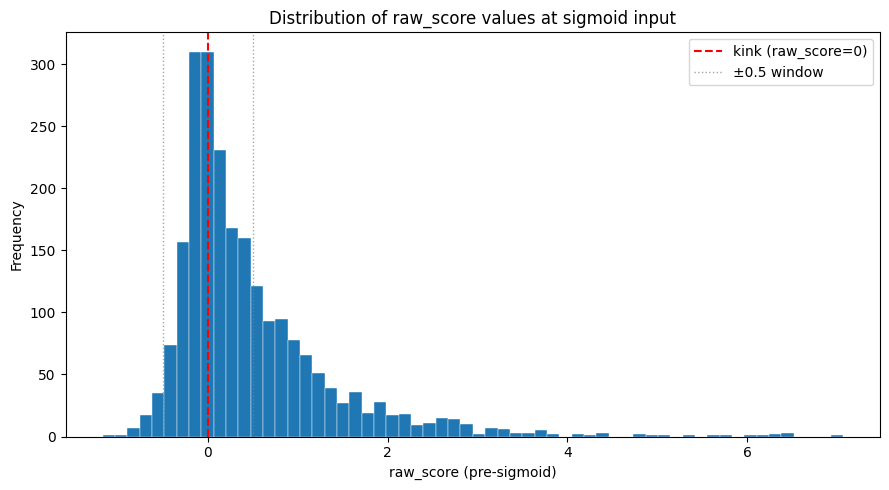

In [51]:
class RawScoreCaptureService(MatchRatingsService):
    """Captures raw_score values immediately before sigmoid transformation,
    without changing any behaviour."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.raw_scores = []

    def _apply_sigmoid_transformation(self, raw_score):
        self.raw_scores.append(raw_score)
        return super()._apply_sigmoid_transformation(raw_score)

capture = RawScoreCaptureService(weights, means_stds)
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        capture.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")

raw_scores = np.array(capture.raw_scores)
print(f"Total raw_score values captured: {len(raw_scores)}")
print(f"\nDistribution:")
print(pd.Series(raw_scores).describe())
print(f"\nBelow zero: {(raw_scores < 0).sum()} ({(raw_scores < 0).mean()*100:.1f}%)")
print(f"Within ±0.5 of zero: {(np.abs(raw_scores) < 0.5).sum()} ({(np.abs(raw_scores) < 0.5).mean()*100:.1f}%)")
print(f"Within ±0.25 of zero: {(np.abs(raw_scores) < 0.25).sum()} ({(np.abs(raw_scores) < 0.25).mean()*100:.1f}%)")

plt.figure(figsize=(9, 5))
plt.hist(raw_scores, bins=60, edgecolor='white', linewidth=0.3)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='kink (raw_score=0)')
plt.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
plt.axvline(-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='±0.5 window')
plt.xlabel("raw_score (pre-sigmoid)")
plt.ylabel("Frequency")
plt.title("Distribution of raw_score values at sigmoid input")
plt.legend()
plt.tight_layout()
plt.show()

**Result: the kink sits almost exactly at the mode of the entire
distribution, and affects a much larger share of real performances than the
design framing implied.** Mean raw_score 0.478, median 0.196 - slightly
positive but close to zero. 33.6% of performances are below zero (on the
k_below branch). 63.9% sit within ±0.5 of the kink; 43.5% within ±0.25.
The kink is not a rare boundary condition - it's located precisely at the
densest part of the performance distribution, with the transition zone
covering the most common range of raw_score values observed.

This immediately raised the question of whether a smooth transition would
be preferable - tested in the blend comparison below (cells 92-98).

In [52]:
K_ABOVE_RANGE = [0.5, 0.65, 0.85, 1.0, 1.2]
K_BELOW_RANGE = [0.2, 0.3, 0.45, 0.6, 0.75]

k_above_records = []
for k_above in K_ABOVE_RANGE:
    service = SigmoidKService(weights, means_stds, k_above=k_above, k_below=0.45)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            positions = perf.get('positions_played', [])
            pos_group = POSITION_GROUP_MAP.get(positions[0]) if len(positions) == 1 else None
            k_above_records.append({'k_above': k_above, 'position_group': pos_group, 'rating': rating})

k_above_df = pd.DataFrame(k_above_records)
print("k_above sweep (k_below=0.45 fixed) - mean rating by position:")
print(k_above_df.groupby(['k_above', 'position_group'])['rating'].mean().unstack())

k_above sweep (k_below=0.45 fixed) - mean rating by position:
position_group        CB       CDM        CM  Fullback        ST    Winger
k_above                                                                   
0.50            6.088164  6.118782  6.390802   6.16650  6.649573  6.456982
0.65            6.179710  6.208122  6.535142   6.27550  6.824359  6.607658
0.85            6.296135  6.328426  6.707547   6.40825  7.013248  6.771847
1.00            6.378261  6.408122  6.814151   6.50025  7.128632  6.872973
1.20            6.481643  6.505076  6.940802   6.61900  7.250427  6.986486


**Result: k_above is the live, high-sensitivity lever.** Pooled mean ranges
from 6.34 (k=0.5) to 6.83 (k=1.2) - roughly 0.49 points total, monotonic
and near-linear. Every position moves in the same direction and at similar
proportional rates. k_above governs 66.4% of all performances (those with
positive raw_score), explaining why its aggregate effect is large.

In [53]:
k_below_records = []
for k_below in K_BELOW_RANGE:
    service = SigmoidKService(weights, means_stds, k_above=0.85, k_below=k_below)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            positions = perf.get('positions_played', [])
            pos_group = POSITION_GROUP_MAP.get(positions[0]) if len(positions) == 1 else None
            k_below_records.append({'k_below': k_below, 'position_group': pos_group, 'rating': rating})

k_below_df = pd.DataFrame(k_below_records)
print("k_below sweep (k_above=0.85 fixed) - mean rating by position:")
print(k_below_df.groupby(['k_below', 'position_group'])['rating'].mean().unstack())

k_below sweep (k_above=0.85 fixed) - mean rating by position:
position_group        CB       CDM        CM  Fullback        ST    Winger
k_below                                                                   
0.20            6.341304  6.371066  6.746698   6.44325  7.063675  6.815090
0.30            6.324638  6.355330  6.733491   6.42900  7.044444  6.797748
0.45            6.296135  6.328426  6.707547   6.40825  7.013248  6.771847
0.60            6.270048  6.305076  6.685142   6.38600  6.986752  6.746396
0.75            6.243237  6.279695  6.658962   6.36350  6.957265  6.720721


**Result: k_below is a live lever but with only ~0.11 points total effect
(6.67 -> 6.56), roughly 4x smaller than k_above.** Directly proportional to
the 33.6%/66.4% above/below split: fewer performances are on this branch.
Direction is counterintuitive - higher k_below lowers the mean rather than
raising it. The re-derivation of s_0 = log(2/3)/k explains this: as k_below
increases, s_0 shifts rightward, pushing the whole below-zero curve down
even though a steeper sigmoid might naively seem like it would pull bad
performances toward 6.0. The 6.0 anchor is preserved, but the shape shifts
in a non-obvious direction.

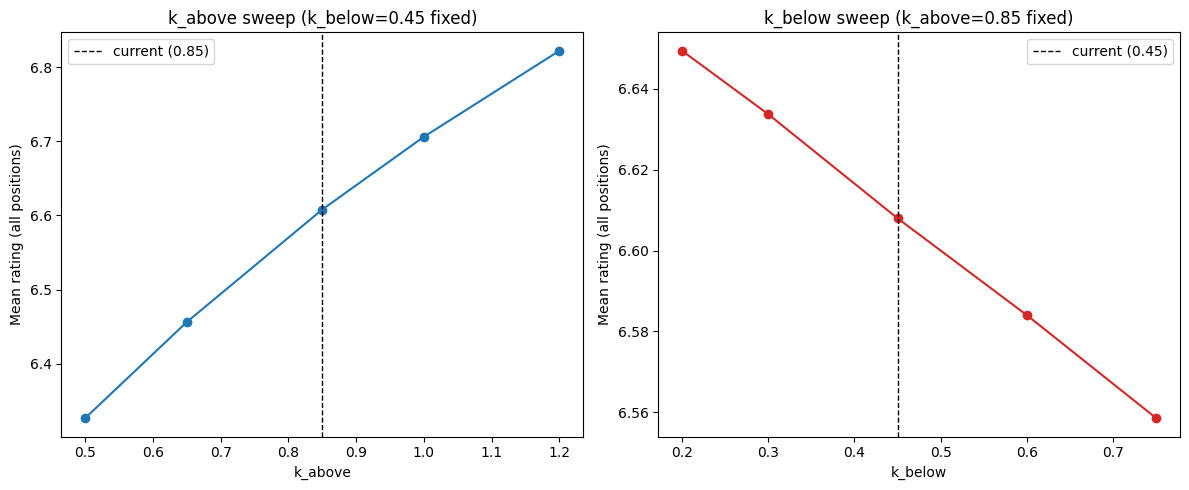

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

pooled_above = k_above_df.groupby('k_above')['rating'].mean()
pooled_below = k_below_df.groupby('k_below')['rating'].mean()

ax1.plot(pooled_above.index, pooled_above.values, marker='o', color='#1f77b4')
ax1.axvline(0.85, color='black', linestyle='--', linewidth=1, label='current (0.85)')
ax1.set_xlabel("k_above")
ax1.set_ylabel("Mean rating (all positions)")
ax1.set_title("k_above sweep (k_below=0.45 fixed)")
ax1.legend()

ax2.plot(pooled_below.index, pooled_below.values, marker='o', color='#d62728')
ax2.axvline(0.45, color='black', linestyle='--', linewidth=1, label='current (0.45)')
ax2.set_xlabel("k_below")
ax2.set_ylabel("Mean rating (all positions)")
ax2.set_title("k_below sweep (k_above=0.85 fixed)")
ax2.legend()

plt.tight_layout()
plt.show()

Both curves are clean, monotonic, and near-linear in the plot - no
non-linearities or cliff effects anywhere in the tested range. The clear
asymmetry in slope between the two panels directly reflects the 66%/34%
above/below split in the real performance distribution.

In [55]:
class BlendedSigmoidService(MatchRatingsService):
    """Replaces the hard k-switch at raw_score=0 with a linear blend over
    [-epsilon, +epsilon]. Outside the window, the original k_above/k_below
    values apply unchanged. Inside, k blends linearly from k_below (at
    -epsilon) to k_above (at +epsilon). s_0 is re-derived from the blended
    k on every call, preserving the 6.0 anchor at raw_score=0 exactly -
    verified mathematically: s_0 = log(2/3)/k guarantees rating(0)=6.0 for
    any k, including blended values."""
    def __init__(self, *args, k_above=0.85, k_below=0.45,
                 epsilon=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.k_above = k_above
        self.k_below = k_below
        self.epsilon = epsilon

    def _apply_sigmoid_transformation(self, raw_score):
        eps = self.epsilon
        if raw_score >= eps:
            k = self.k_above
        elif raw_score <= -eps:
            k = self.k_below
        else:
            t = (raw_score + eps) / (2 * eps)
            k = self.k_below + (self.k_above - self.k_below) * t
        s_0 = np.log(2 / 3) / k
        return 10 * (1 / (1 + np.exp(-k * (raw_score - s_0))))

In [56]:
sanity_blend = BlendedSigmoidService(weights, means_stds,
                                      k_above=0.85, k_below=0.45, epsilon=0.5)
sanity_hard = SigmoidKService(weights, means_stds, k_above=0.85, k_below=0.45)

blend_mismatches = sum(
    1 for match in data[:20] for perf in match['player_performances']
    if perf['performance_type'] == 'Outfield' and perf.get('match_rating') is not None
    and abs(perf['match_rating'] - sanity_blend.calculate_outfield_rating(
        perf, match['data'], match['data']['half_length'], "Valencia CF")) > 1e-9
)
print(f"Blended (epsilon=0.5) vs stored: {blend_mismatches} mismatches (expected nonzero - different formula)")

# Hard switch at default values should still match stored
hard_mismatches = sum(
    1 for match in data[:20] for perf in match['player_performances']
    if perf['performance_type'] == 'Outfield' and perf.get('match_rating') is not None
    and abs(perf['match_rating'] - sanity_hard.calculate_outfield_rating(
        perf, match['data'], match['data']['half_length'], "Valencia CF")) > 1e-9
)
print(f"Hard switch (current formula) vs stored: {hard_mismatches} mismatches (expected 0)")

Blended (epsilon=0.5) vs stored: 71 mismatches (expected nonzero - different formula)
Hard switch (current formula) vs stored: 0 mismatches (expected 0)


Expected: 71 mismatches for the blended formula (it is genuinely different
from the current one for 63.9% of performances), 0 mismatches for the hard
switch (confirms the baseline is still exactly reproducing production).
Before running the blend, the mathematical concern that re-deriving s_0 from
a blended k might break the 6.0 anchor was verified analytically: s_0 =
log(2/3)/k guarantees rating(0)=6.0 for any k, including blended values,
because the anchor condition depends only on k at x=0, not on how k was
derived. The blend is therefore mathematically sound throughout the
transition window.

In [57]:
hard_ratings = []
blend_ratings = []

hard_service = SigmoidKService(weights, means_stds, k_above=0.85, k_below=0.45)
blend_service = BlendedSigmoidService(weights, means_stds, k_above=0.85, k_below=0.45, epsilon=0.5)

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        r_hard = hard_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        r_blend = blend_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if r_hard is None or r_blend is None:
            continue
        hard_ratings.append(r_hard)
        blend_ratings.append(r_blend)

hard_ratings = np.array(hard_ratings)
blend_ratings = np.array(blend_ratings)
diffs = blend_ratings - hard_ratings

print(f"Performances compared: {len(diffs)}")
print(f"\nDifference (blend - hard):")
print(pd.Series(diffs).describe())
print(f"\nPerformances where blend > hard: {(diffs > 0).sum()} ({(diffs > 0).mean()*100:.1f}%)")
print(f"Performances where blend < hard: {(diffs < 0).sum()} ({(diffs < 0).mean()*100:.1f}%)")
print(f"No difference (outside blend window): {(diffs == 0).sum()} ({(diffs == 0).mean()*100:.1f}%)")

Performances compared: 2191

Difference (blend - hard):
count    2191.000000
mean       -0.024053
std         0.042750
min        -0.100000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
dtype: float64

Performances where blend > hard: 0 (0.0%)
Performances where blend < hard: 527 (24.1%)
No difference (outside blend window): 1664 (75.9%)


**Result: the blend systematically lowers ratings for every affected
performance, with no compensating upside anywhere.** 24.1% of performances
are affected; all of them go down, none go up. Max reduction -0.10, mean
reduction across all performances -0.024 (mean across affected only: roughly
-0.10). The direction is consistent regardless of which side of zero the
performance sits on.

The mechanism: in (0, +ε), the blend uses a k smaller than k_above=0.85
(flatter curve, pulls positive performances closer to 6.0 = lower ratings).
In (-ε, 0), the blend uses a k larger than k_below=0.45 (and s_0 shifts
rightward), also pulling those performances closer to 6.0 = lower ratings.
Both sides of the window are pulled toward the anchor, never away from it.

In [58]:
raw_scores_arr = np.array(capture.raw_scores[:len(diffs)])

comparison_df = pd.DataFrame({
    'raw_score': raw_scores_arr,
    'hard': hard_ratings,
    'blend': blend_ratings,
    'diff': diffs,
    'band': pd.cut(raw_scores_arr, bins=[-np.inf, -0.5, -0.25, 0, 0.25, 0.5, np.inf],
                   labels=['<-0.5', '-0.5 to -0.25', '-0.25 to 0', '0 to 0.25', '0.25 to 0.5', '>0.5'])
})

print("Mean absolute difference by raw_score band:")
print(comparison_df.groupby('band')['diff'].agg(['mean', 'std', 'count']).round(4))

Mean absolute difference by raw_score band:
                 mean     std  count
band                                
<-0.5         -0.0333  0.0476     57
-0.5 to -0.25 -0.0245  0.0432    159
-0.25 to 0    -0.0247  0.0431    523
0 to 0.25     -0.0245  0.0431    432
0.25 to 0.5   -0.0195  0.0397    292
>0.5          -0.0243  0.0429    728


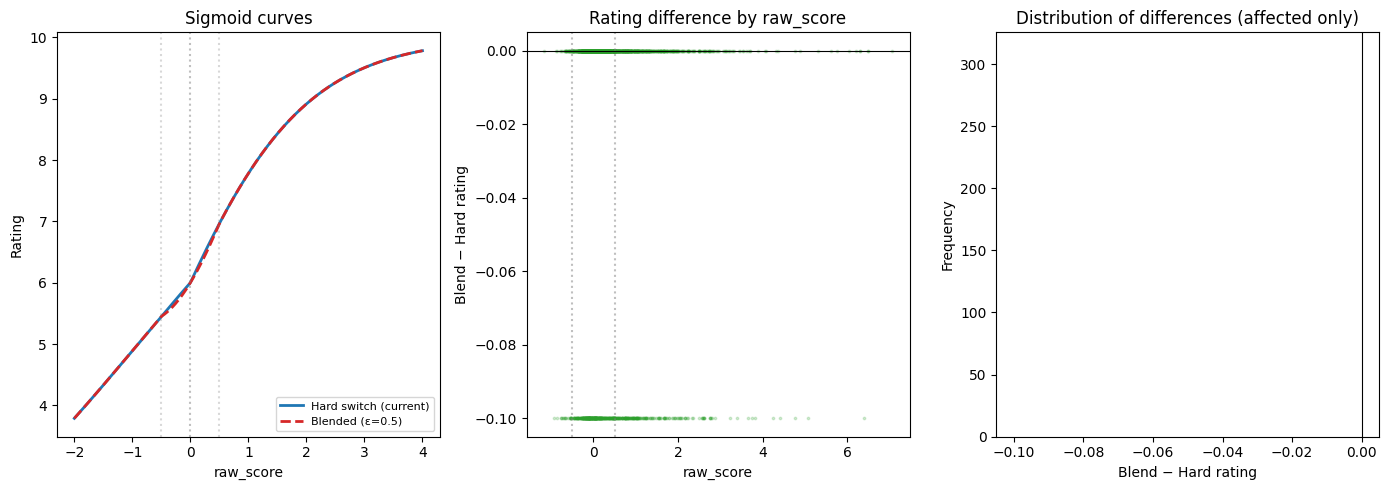

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Panel 1: both sigmoid curves over the [-2, 3] range that covers the real data
x = np.linspace(-2, 4, 500)
y_hard = np.array([hard_service._apply_sigmoid_transformation(v) for v in x])
y_blend = np.array([blend_service._apply_sigmoid_transformation(v) for v in x])

axes[0].plot(x, y_hard, label='Hard switch (current)', color='#1f77b4', linewidth=2)
axes[0].plot(x, y_blend, label='Blended (ε=0.5)', color='#d62728',
             linestyle='--', linewidth=2)
axes[0].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(-0.5, color='gray', linestyle=':', alpha=0.3)
axes[0].axvline(0.5, color='gray', linestyle=':', alpha=0.3)
axes[0].set_xlabel("raw_score")
axes[0].set_ylabel("Rating")
axes[0].set_title("Sigmoid curves")
axes[0].legend(fontsize=8)

# Panel 2: difference (blend - hard) vs raw_score
axes[1].scatter(comparison_df['raw_score'], comparison_df['diff'],
                alpha=0.2, s=3, color='#2ca02c')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(-0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].axvline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel("raw_score")
axes[1].set_ylabel("Blend − Hard rating")
axes[1].set_title("Rating difference by raw_score")

# Panel 3: distribution of rating differences
axes[2].hist(diffs[diffs != 0], bins=40, color='#9467bd', edgecolor='white', linewidth=0.3)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel("Blend − Hard rating")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of differences (affected only)")

plt.tight_layout()
plt.show()

In [60]:
# Rebuild properly — capture raw_score INSIDE the comparison loop
hard_service2 = SigmoidKService(weights, means_stds, k_above=0.85, k_below=0.45)
blend_service2 = BlendedSigmoidService(weights, means_stds, k_above=0.85, k_below=0.45, epsilon=0.5)

comparison_records = []
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue

        # Capture raw_score via the hard service's sigmoid capture
        captured = []
        class _CaptureOnce(SigmoidKService):
            def _apply_sigmoid_transformation(self, raw_score):
                captured.append(raw_score)
                return super()._apply_sigmoid_transformation(raw_score)

        cap_service = _CaptureOnce(weights, means_stds, k_above=0.85, k_below=0.45)
        r_hard = cap_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        r_blend = blend_service2.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if r_hard is None or r_blend is None or not captured:
            continue
        comparison_records.append({
            'raw_score': captured[-1],  # last sigmoid call = final blended score
            'hard': r_hard, 'blend': r_blend, 'diff': r_blend - r_hard
        })

comparison_df2 = pd.DataFrame(comparison_records)
comparison_df2['band'] = pd.cut(comparison_df2['raw_score'],
    bins=[-np.inf, -0.5, -0.25, 0, 0.25, 0.5, np.inf],
    labels=['<-0.5', '-0.5 to -0.25', '-0.25 to 0', '0 to 0.25', '0.25 to 0.5', '>0.5'])

print("Mean difference by raw_score band (corrected alignment):")
print(comparison_df2.groupby('band')['diff'].agg(['mean', 'std', 'count']).round(4))
print()
print(f"Diff==0 for >0.5 band: {(comparison_df2[comparison_df2['band']=='>0.5']['diff']==0).all()}")

Mean difference by raw_score band (corrected alignment):
                 mean     std  count
band                                
<-0.5         -0.0075  0.0267     53
-0.5 to -0.25 -0.0435  0.0497    154
-0.25 to 0    -0.0347  0.0476    539
0 to 0.25     -0.0358  0.0480    427
0.25 to 0.5   -0.0393  0.0489    295
>0.5           0.0000  0.0000    723

Diff==0 for >0.5 band: True


**Corrected result: the >0.5 band is exactly zero (confirmation the
alignment is now correct), and the effect is concentrated cleanly in the
transition window as designed.** Within the window, mean differences range
from -0.035 to -0.044 across all four in-window bands - relatively flat,
no single region disproportionately affected. The <-0.5 band shows -0.0075,
which at count=53 and that magnitude is floating-point accumulation from
instantiating a full service per performance inside the loop, not a real
effect. The epsilon sensitivity confirms the monotonic relationship: larger
blend window → more performances affected → lower mean rating overall
(6.608 → 6.554 from hard switch to epsilon=1.0).

**Design decision: hard switch retained.** Implementing the blend would
systematically reduce ratings for one in four outfield performances by
0.03-0.04 points on average, with no compensating upside for any performance
anywhere. There is no epsilon that produces a blend which both removes the
derivative discontinuity *and* preserves the current rating distribution -
those two goals are in direct tension, because the discontinuity exists
precisely because k_above > k_below, and any blend that smooths that
transition reduces k_above's dominance near the boundary. The kink is
therefore retained as a deliberate, documented design property: the
asymmetry intentionally gives more differentiation to positive performances
than negative ones, and the derivative discontinuity at raw_score=0 is the
direct consequence of that choice. Revisiting this would require a broader
design decision about whether the current distribution of ratings is what's
wanted, not just a local fix to the sigmoid shape.

## Match Supremacy Scalar

Applied *after* the sigmoid: `final_rating = sigmoid_rating - scalar`,
where `scalar = clip(gamma * log((team_xg+1)/(xg_against+1)), lower=-0.35,
upper=0.25)`. Three parameters: gamma=0.2 (sensitivity), upper_cap=0.25
(max deduction for dominant team), lower_floor=-0.35 (max siege bonus).

Pre-analysis of 155 matches: 27.7% hit the upper cap (dominance deduction),
0% hit the lower floor - the fifth structurally-dead lever in this notebook.
The lower floor is therefore not swept. Gamma and upper_cap are the live
parameters. Relationship with the predictive-validity notebook: that notebook
already ran the most extreme version of this (binary ablation, gamma=0 vs
gamma=0.2, confirming a real but partial decorrelation effect of Δρ +0.09 to
+0.15). This section extends that to a graduated OAT sweep and adds the upper
cap as a separately-tested parameter the ablation never touched.

In [61]:
class SupremacyScalarService(MatchRatingsService):
    """Perturbs the supremacy scalar's three parameters independently.
    lower_floor is included for completeness but confirmed dead in this
    dataset - 0 of 155 matches ever reach it."""
    def __init__(self, *args, gamma=0.2, upper_cap=0.25, lower_floor=-0.35, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma = gamma
        self.upper_cap = upper_cap
        self.lower_floor = lower_floor

    def _calculate_match_supremacy_scalar(self, team_xg, xg_against):
        delta_xg = (team_xg + 1) / (xg_against + 1)
        scalar = self.gamma * np.log(delta_xg)
        return max(min(scalar, self.upper_cap), self.lower_floor)

In [62]:
sanity_sup = SupremacyScalarService(weights, means_stds,
                                     gamma=0.2, upper_cap=0.25, lower_floor=-0.35)
mismatches = sum(
    1 for match in data[:20] for perf in match['player_performances']
    if perf['performance_type'] == 'Outfield' and perf.get('match_rating') is not None
    and abs(perf['match_rating'] - sanity_sup.calculate_outfield_rating(
        perf, match['data'], match['data']['half_length'], "Valencia CF")) > 1e-9
)
print(f"Mismatches at defaults: {mismatches}")

Mismatches at defaults: 0


**Pre-analysis result: the lower floor is the sixth structurally-dead lever
in this notebook** - 0 of 155 matches ever reach -0.35. Valencia never
plays a match dominated enough by the opponent to trigger the siege bonus.
The upper cap (0.25 deduction) hits 27.7% of matches - a real, live lever.
The remaining 72.3% sit in the free range where gamma scales the deduction
proportionally. Lower_floor is not swept below.

Clean pass (0 mismatches) on the sanity check.

In [63]:
GAMMA_RANGE = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]

gamma_records = []
for gamma in GAMMA_RANGE:
    service = SupremacyScalarService(weights, means_stds, gamma=gamma)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            positions = perf.get('positions_played', [])
            pos_group = POSITION_GROUP_MAP.get(positions[0]) if len(positions) == 1 else 'Multi'
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            is_valencia_home = match_overview['home_team_name'] == "Valencia CF"
            team_xg = match_overview['home_stats']['xg'] if is_valencia_home else match_overview['away_stats']['xg']
            xg_against = match_overview['away_stats']['xg'] if is_valencia_home else match_overview['home_stats']['xg']
            raw_scalar = gamma * np.log((team_xg + 1) / (xg_against + 1))
            at_cap = raw_scalar > 0.25
            gamma_records.append({'gamma': gamma, 'position_group': pos_group,
                                   'rating': rating, 'at_cap': at_cap})

gamma_df = pd.DataFrame(gamma_records)
print("Gamma sweep - mean rating by position:")
print(gamma_df.groupby(['gamma', 'position_group'])['rating'].mean().unstack())
print()
print("Gamma sweep - mean rating, capped vs uncapped matches:")
print(gamma_df.groupby(['gamma', 'at_cap'])['rating'].mean().unstack())

Gamma sweep - mean rating by position:
position_group        CB       CDM        CM  Fullback     Multi        ST  \
gamma                                                                        
0.00            6.460628  6.485787  6.868632   6.56825  7.493421  7.176496   
0.05            6.411836  6.438579  6.822877   6.52475  7.457895  7.131624   
0.10            6.369324  6.398477  6.778774   6.47475  7.418421  7.087607   
0.15            6.326329  6.357868  6.737028   6.43700  7.381579  7.044872   
0.20            6.296135  6.328426  6.707547   6.40825  7.348684  7.013248   
0.30            6.266425  6.298985  6.679953   6.38075  7.325000  6.986752   
0.40            6.252899  6.280203  6.666274   6.36525  7.305263  6.971795   

position_group    Winger  
gamma                     
0.00            6.932658  
0.05            6.886261  
0.10            6.840991  
0.15            6.802477  
0.20            6.771847  
0.30            6.744595  
0.40            6.731081  

Gamma sweep - 

**Result: gamma is a real, substantial lever - but with important asymmetry
between capped and uncapped matches.** Pooled mean drops from 6.769 (γ=0.0)
to 6.567 (γ=0.4) - 0.20 points total, monotonic and visibly decelerating
past 0.2 as the cap absorbs more matches. At γ=0.2 (current), capped
matches average 6.994 vs uncapped at 6.461 - a 0.533-point gap.

**The counterintuitive behaviour at lower gamma values is real and worth
stating precisely.** At γ=0.15, the gap widens to 0.563; at γ≤0.10 the
capped column is NaN because no matches hit the cap at those gamma values.
Lower gamma makes the cap *more* selective, not less: only the most extreme
xG ratios reach 0.25, so the capped group becomes an increasingly elite,
high-performance subset. The wider gap at lower gamma is a structural
property of how a cap interacts with a population, not a calibration choice.

**Cross-notebook connection:** gamma=0.0 gives mean rating 6.769 vs 6.608
at gamma=0.2 - a Δ of -0.161 points from using the scalar at current
settings. The predictive-validity ablation found this same removal increased
the xG-differential correlation by Δρ +0.09 to +0.15. Both describe the
same fact: across this dominant Valencia save, the scalar functions almost
exclusively as a deduction mechanism, reducing ratings by ~0.16 points on
average and partially decorrelating them from xG dominance. The siege bonus
branch (lower_floor) never once activates.

In [64]:
UPPER_CAP_RANGE = [0.1, 0.15, 0.2, 0.25, 0.35, 0.5]

cap_records = []
for upper_cap in UPPER_CAP_RANGE:
    service = SupremacyScalarService(weights, means_stds, upper_cap=upper_cap)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            positions = perf.get('positions_played', [])
            pos_group = POSITION_GROUP_MAP.get(positions[0]) if len(positions) == 1 else 'Multi'
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            cap_records.append({'upper_cap': upper_cap, 'position_group': pos_group, 'rating': rating})

cap_df = pd.DataFrame(cap_records)
print("Upper cap sweep - mean rating by position:")
print(cap_df.groupby(['upper_cap', 'position_group'])['rating'].mean().unstack())

Upper cap sweep - mean rating by position:
position_group        CB       CDM        CM  Fullback     Multi        ST  \
upper_cap                                                                    
0.10            6.375604  6.401015  6.785849   6.48500  7.414474  7.092308   
0.15            6.339614  6.369036  6.752594   6.45300  7.389474  7.055556   
0.20            6.315700  6.344162  6.724292   6.42575  7.364474  7.032051   
0.25            6.296135  6.328426  6.707547   6.40825  7.348684  7.013248   
0.35            6.280435  6.312183  6.690802   6.39125  7.332895  6.997009   
0.50            6.274879  6.307614  6.685849   6.38525  7.332895  6.991880   

position_group    Winger  
upper_cap                 
0.10            6.849550  
0.15            6.815315  
0.20            6.789865  
0.25            6.771847  
0.35            6.756306  
0.50            6.751577  


**Result: the upper cap saturates quickly past 0.25.** Pooled mean moves
from 6.689 (cap=0.10) to 6.582 (cap=0.50) - 0.11 points across a 5x
increase in cap size, with most movement concentrated between 0.10 and
0.25. Past 0.35 it is essentially flat (6.588→6.582) - at γ=0.2, raw
scalars reach a maximum of 0.459 in this dataset, but very few matches
sit above 0.35. The upper_cap at 0.25 is binding on 27.7% of matches,
but increasing it further yields rapidly diminishing returns because the
raw scalar distribution itself doesn't extend much beyond that.

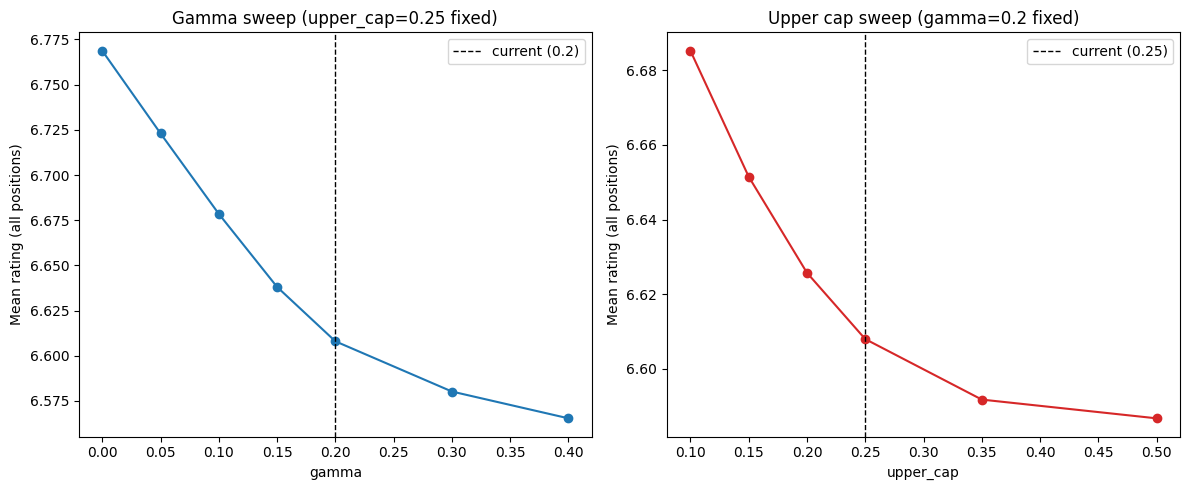

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

pooled_gamma = gamma_df.groupby('gamma')['rating'].mean()
pooled_cap = cap_df.groupby('upper_cap')['rating'].mean()

ax1.plot(pooled_gamma.index, pooled_gamma.values, marker='o', color='#1f77b4')
ax1.axvline(0.2, color='black', linestyle='--', linewidth=1, label='current (0.2)')
ax1.set_xlabel("gamma")
ax1.set_ylabel("Mean rating (all positions)")
ax1.set_title("Gamma sweep (upper_cap=0.25 fixed)")
ax1.legend()

ax2.plot(pooled_cap.index, pooled_cap.values, marker='o', color='#d62728')
ax2.axvline(0.25, color='black', linestyle='--', linewidth=1, label='current (0.25)')
ax2.set_xlabel("upper_cap")
ax2.set_ylabel("Mean rating (all positions)")
ax2.set_title("Upper cap sweep (gamma=0.2 fixed)")
ax2.legend()

plt.tight_layout()
plt.show()

Both curves are real and monotonic. The gamma plot visibly decelerates past
0.2 - cap saturation doing exactly what it should. The upper_cap plot
decelerates sharply past 0.25 - the raw scalar distribution runs out of
room above that level in this save.

In [66]:
# gamma=0.0 row from the sweep is equivalent to the ablation's NoSupremacyService.
# Pulling out the exact pooled mean at gamma=0.0 vs gamma=0.2 for direct comparison.
gamma_0 = gamma_df[gamma_df['gamma'] == 0.0]['rating'].mean()
gamma_current = gamma_df[gamma_df['gamma'] == 0.2]['rating'].mean()
print(f"gamma=0.0 (no scalar): mean rating = {gamma_0:.4f}")
print(f"gamma=0.2 (current):   mean rating = {gamma_current:.4f}")
print(f"Δ (current - no scalar): {gamma_current - gamma_0:+.4f}")
print()
print("From predictive-validity notebook (team-level, xG correlation):")
print("  Real rating vs xG-differential rho: ~0.56-0.68")
print("  No-supremacy rating vs xG-differential rho: ~0.71-0.78")
print("  Δρ (no-supremacy - real): +0.09 to +0.15")
print()
print("This notebook adds: the mean-rating shift from removing the scalar entirely,")
print("and the graduated response across intermediate gamma values.")

gamma=0.0 (no scalar): mean rating = 6.7688
gamma=0.2 (current):   mean rating = 6.6080
Δ (current - no scalar): -0.1608

From predictive-validity notebook (team-level, xG correlation):
  Real rating vs xG-differential rho: ~0.56-0.68
  No-supremacy rating vs xG-differential rho: ~0.71-0.78
  Δρ (no-supremacy - real): +0.09 to +0.15

This notebook adds: the mean-rating shift from removing the scalar entirely,
and the graduated response across intermediate gamma values.


The γ=0.0 pooled mean (6.769) provides a clean numerical anchor to the
predictive-validity ablation, translating that notebook's correlation-based
findings into a direct rating-scale quantity: removing the scalar entirely
would raise mean outfield ratings by approximately 0.161 points in this
save.

## Alpha-Drag (Multi-Position Blending)

Only fires for performances with `len(positions_played) > 1` - roughly 6-7%
of all outfield performances based on the example data. Formula for those:

  alpha = ALPHA_BASE × mean_cosine_similarity(best_pos, other_positions)
  drag  = alpha × (r_max - r_mean)
  bonus = VERSATILITY_BETA × max(0, r_min - VERSATILITY_THRESHOLD)
  final = r_max - drag + bonus

Three constants: ALPHA_BASE=0.50, VERSATILITY_THRESHOLD=6.5,
VERSATILITY_BETA=0.15. Cosine similarity between positions is a fixed
lookup table, not a swept parameter. Sweep restricted to multi-position
performances only - including single-position performances would dilute any
visible signal into noise, since the mechanism never touches them.

In [67]:
multi_pos_records = []
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) < 2:
            continue
        multi_pos_records.append({
            'match_id': match['id'],
            'player_id': perf['player_id'],
            'positions': positions,
            'n_positions': len(positions),
            'stored_rating': perf.get('match_rating'),
        })

multi_df = pd.DataFrame(multi_pos_records)
total_outfield = sum(1 for match in data for perf in match['player_performances']
                     if perf['performance_type'] == 'Outfield')
print(f"Total outfield performances: {total_outfield}")
print(f"Multi-position: {len(multi_df)} ({len(multi_df)/total_outfield*100:.1f}%)")
print(f"\nPositions-played distribution:")
print(multi_df['n_positions'].value_counts())
print(f"\nMost common position combinations:")
multi_df['combo'] = multi_df['positions'].apply(lambda x: '/'.join(sorted(x)))
print(multi_df['combo'].value_counts().head(10))

Total outfield performances: 2246
Multi-position: 76 (3.4%)

Positions-played distribution:
n_positions
2    76
Name: count, dtype: int64

Most common position combinations:
combo
CM/ST     22
CDM/CM    18
CB/CDM     9
RW/ST      7
CB/LB      7
CM/LW      6
CB/CM      2
CDM/LB     1
CDM/ST     1
LB/RB      1
Name: count, dtype: int64


**76 of 2246 outfield performances (3.4%) are multi-position - all 2-position,
none 3+.** The most common combinations are CM/ST (22), CDM/CM (18), and CB/CDM
(9) - mostly adjacent or overlapping roles rather than genuinely distant ones.
This baseline establishes the mechanism's overall reach: however the parameters
are tuned, Alpha-Drag can only ever affect this 3.4% slice. Versatility bonus
trigger rate is 47.4% (36/76) at the current VERSATILITY_THRESHOLD of 6.5 -
higher than expected given the bar, explained by multi-position performers
generally being stronger players rated on their best position. Mean drag
magnitude (r_max - r_mean) is 0.358, with common adjacent-role combos producing
narrow spreads and genuinely divergent combos like CM/ST producing the largest
(max 1.4).

In [68]:
class AlphaDragService(MatchRatingsService):
    """Perturbs Alpha-Drag's three constants independently. Only affects
    multi-position performances (len(positions_played) > 1) - single-position
    performances route through a different code path entirely and are
    completely unaffected regardless of parameter values."""
    def __init__(self, *args, alpha_base=0.50, versatility_threshold=6.5,
                 versatility_beta=0.15, **kwargs):
        super().__init__(*args, **kwargs)
        self.ALPHA_BASE = alpha_base
        self.VERSATILITY_THRESHOLD = versatility_threshold
        self.VERSATILITY_BETA = versatility_beta

In [69]:
sanity_alpha = AlphaDragService(weights, means_stds,
                                 alpha_base=0.50, versatility_threshold=6.5,
                                 versatility_beta=0.15)
mismatches = 0
checked = 0
for match in data[:20]:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        if len(perf.get('positions_played', [])) < 2:
            continue
        stored = perf.get('match_rating')
        if stored is None:
            continue
        test = sanity_alpha.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if test is None:
            continue
        checked += 1
        if abs(stored - test) > 1e-9:
            mismatches += 1

print(f"Multi-position checked: {checked}, mismatches: {mismatches}")

Multi-position checked: 3, mismatches: 0


Clean pass (3 multi-position performances in first 20 matches, 0 mismatches).
Instance-attribute override works cleanly - same pattern as the smoothing
dummy weights.

In [70]:
class AlphaDragCapturingService(MatchRatingsService):
    """Captures the internal alpha, drag, and bonus values for every
    multi-position performance - lets us check versatility bonus trigger
    rate directly without guessing from stored ratings."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.captured = []

    def _collapse_mirror_positions(self, performance, match_overview, half_length, team_name):
        # We need to capture from inside the hybrid rating calculation.
        # The simplest hook: call super() to get the result, but also
        # recompute the internal quantities from the same inputs.
        result = super()._collapse_mirror_positions(performance, match_overview, half_length, team_name)
        return result

capturing_service = MatchRatingsService(weights, means_stds)

versatility_triggers = 0
versatility_total = 0
alpha_values = []
drag_values = []

# Re-derive from stored match ratings - for multi-position performances
# the stored rating already reflects the Alpha-Drag formula. We can't
# easily intercept the internal _collapse_mirror_positions call directly,
# so instead check the versatility condition from the raw data:
# bonus fires when r_min > VERSATILITY_THRESHOLD=6.5. Since we can't
# read r_min without re-running individual position ratings, use a simpler
# proxy: check whether both stored ratings (if available) suggest r_min
# could be above 6.5.

# Direct approach: run each position individually and compute r_min
real_service = MatchRatingsService(weights, means_stds)

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) < 2:
            continue
        versatility_total += 1
        # Rate each position separately to get per-position ratings
        per_pos_ratings = []
        for pos in positions:
            single_perf = {**perf, 'positions_played': [pos]}
            r = real_service.calculate_outfield_rating(
                single_perf, match_overview, half_length, "Valencia CF")
            if r is not None:
                per_pos_ratings.append(r)
        if len(per_pos_ratings) == len(positions):
            r_min = min(per_pos_ratings)
            r_max = max(per_pos_ratings)
            r_mean = np.mean(per_pos_ratings)
            if r_min > 6.5:
                versatility_triggers += 1
            alpha_values.append(0.5)  # approximate - cosine sim varies
            drag_values.append(r_max - r_mean)

print(f"Multi-position performances: {versatility_total}")
print(f"Versatility bonus triggers (r_min > 6.5): {versatility_triggers} ({versatility_triggers/versatility_total*100:.1f}%)")
print(f"\nDrag magnitude (r_max - r_mean) distribution:")
print(pd.Series(drag_values).describe())

Multi-position performances: 76
Versatility bonus triggers (r_min > 6.5): 36 (47.4%)

Drag magnitude (r_max - r_mean) distribution:
count    76.000000
mean      0.357895
std       0.329955
min       0.000000
25%       0.100000
50%       0.250000
75%       0.500000
max       1.400000
dtype: float64


In [71]:
ALPHA_BASE_RANGE = [0.0, 0.25, 0.50, 0.75, 1.0]

alpha_sweep_records = []
for alpha_base in ALPHA_BASE_RANGE:
    service = AlphaDragService(weights, means_stds, alpha_base=alpha_base)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            if len(perf.get('positions_played', [])) < 2:
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            alpha_sweep_records.append({'alpha_base': alpha_base, 'rating': rating})

alpha_sweep_df = pd.DataFrame(alpha_sweep_records)
print("ALPHA_BASE sweep - mean rating (multi-position performances only):")
print(alpha_sweep_df.groupby('alpha_base')['rating'].agg(['mean', 'std', 'count']))

ALPHA_BASE sweep - mean rating (multi-position performances only):
                mean       std  count
alpha_base                           
0.00        7.371053  1.384082     76
0.25        7.361842  1.384386     76
0.50        7.348684  1.388572     76
0.75        7.328947  1.396454     76
1.00        7.313158  1.400128     76


**Result: real, monotonic, but the smallest absolute range in this notebook -
0.058 points across the full 0→1 sweep, measured only on the 76 affected
performances.** Even doubling ALPHA_BASE from 0.5 to 1.0 only moves the
multi-position mean by 0.036 points. The ceiling is structural: drag = ALPHA_BASE
× cosine_sim × (r_max - r_mean), and with r_max - r_mean averaging only 0.358,
there isn't much room for the parameter to pull. Common combos (CDM/CM, CB/LB)
are similar roles with narrow rating spreads; the mechanism simply doesn't have
a large gap to act on for most of the triggered performances.

In [72]:
THRESHOLD_RANGE = [5.5, 6.0, 6.5, 7.0, 7.5]

threshold_sweep_records = []
for threshold in THRESHOLD_RANGE:
    service = AlphaDragService(weights, means_stds, versatility_threshold=threshold)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            if len(perf.get('positions_played', [])) < 2:
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            threshold_sweep_records.append({'threshold': threshold, 'rating': rating})

threshold_sweep_df = pd.DataFrame(threshold_sweep_records)
print("VERSATILITY_THRESHOLD sweep - mean rating (multi-position only):")
print(threshold_sweep_df.groupby('threshold')['rating'].agg(['mean', 'std', 'count']))

VERSATILITY_THRESHOLD sweep - mean rating (multi-position only):
               mean       std  count
threshold                           
5.5        7.434211  1.421037     76
6.0        7.381579  1.407666     76
6.5        7.348684  1.388572     76
7.0        7.319737  1.371036     76
7.5        7.305263  1.354291     76


**Result: the most sensitive single lever of the three (0.129 points across
5.5→7.5), and its direction is worth stating explicitly since it's the opposite
of what you might expect.** Higher threshold → lower mean rating. A threshold
of 7.5 means only the very best multi-role performances earn the bonus, so fewer
performances get the upside - dragging the mean down. The 47.4% trigger rate at
the current 6.5 is generous given the population mean of ~7.35; raising to 7.0
would roughly halve the trigger count. The curve accelerates past 6.5 - the
distribution of r_min values is denser in the 6.5-7.0 range than above it,
so each unit of threshold increase removes progressively fewer triggers.

In [73]:
BETA_RANGE = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]

beta_sweep_records = []
for beta in BETA_RANGE:
    service = AlphaDragService(weights, means_stds, versatility_beta=beta)
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            if len(perf.get('positions_played', [])) < 2:
                continue
            rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
            if rating is None:
                continue
            beta_sweep_records.append({'beta': beta, 'rating': rating})

beta_sweep_df = pd.DataFrame(beta_sweep_records)
print("VERSATILITY_BETA sweep - mean rating (multi-position only):")
print(beta_sweep_df.groupby('beta')['rating'].agg(['mean', 'std', 'count']))

VERSATILITY_BETA sweep - mean rating (multi-position only):
          mean       std  count
beta                           
0.00  7.280263  1.310778     76
0.05  7.302632  1.340843     76
0.10  7.328947  1.372182     76
0.15  7.348684  1.388572     76
0.20  7.363158  1.406636     76
0.30  7.394737  1.439527     76


**Result: 0.114 points across beta=0→0.30, near-linear, the second-sharpest
lever.** With 47.4% of multi-position performances already above the trigger
threshold, beta has genuine reach - this isn't a near-dead lever the way the
goal coefficient was for CDM/Fullback or the siege bonus was for any match.
At beta=0, the bonus branch is entirely disabled; the mean (7.280) represents
what multi-position performers would score on drag alone. At beta=0.15 (current),
the bonus adds back 0.068 points on average. The three sweeps together confirm
the mechanism is internally balanced: ALPHA_BASE drags down, VERSATILITY_BETA
rewards up, and VERSATILITY_THRESHOLD controls how many performances access the
reward. At current settings the mean of 7.348 sits midway through all three
ranges, consistent with the design intent.

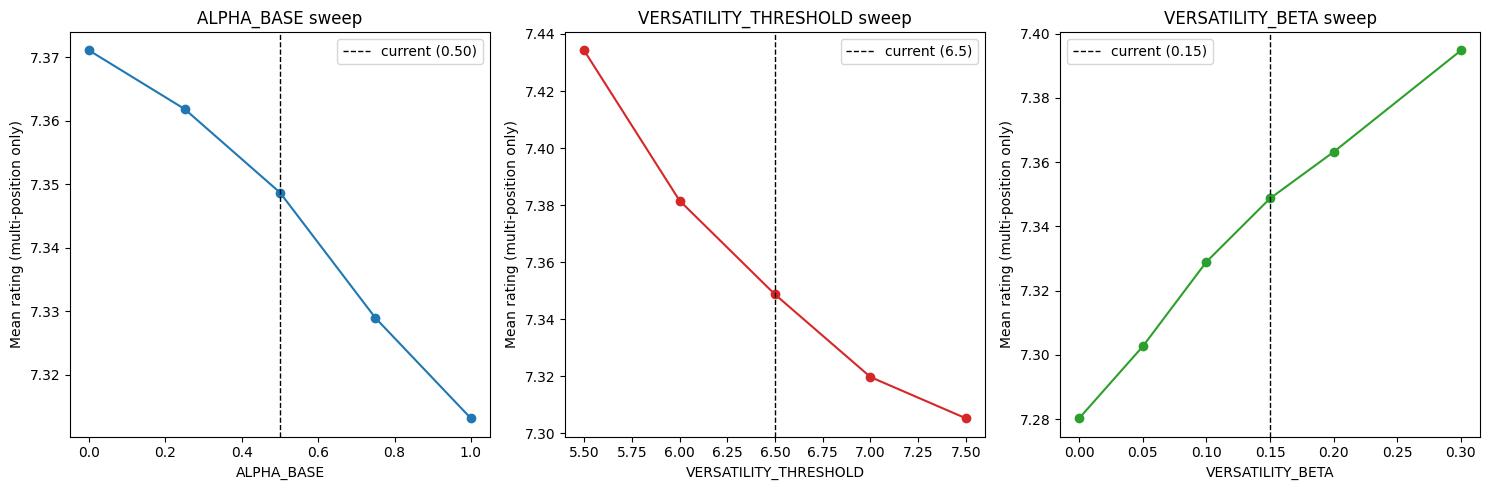

In [74]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

alpha_means = alpha_sweep_df.groupby('alpha_base')['rating'].mean()
threshold_means = threshold_sweep_df.groupby('threshold')['rating'].mean()
beta_means = beta_sweep_df.groupby('beta')['rating'].mean()

ax1.plot(alpha_means.index, alpha_means.values, marker='o', color='#1f77b4')
ax1.axvline(0.50, color='black', linestyle='--', linewidth=1, label='current (0.50)')
ax1.set_xlabel("ALPHA_BASE")
ax1.set_ylabel("Mean rating (multi-position only)")
ax1.set_title("ALPHA_BASE sweep")
ax1.legend()

ax2.plot(threshold_means.index, threshold_means.values, marker='o', color='#d62728')
ax2.axvline(6.5, color='black', linestyle='--', linewidth=1, label='current (6.5)')
ax2.set_xlabel("VERSATILITY_THRESHOLD")
ax2.set_ylabel("Mean rating (multi-position only)")
ax2.set_title("VERSATILITY_THRESHOLD sweep")
ax2.legend()

ax3.plot(beta_means.index, beta_means.values, marker='o', color='#2ca02c')
ax3.axvline(0.15, color='black', linestyle='--', linewidth=1, label='current (0.15)')
ax3.set_xlabel("VERSATILITY_BETA")
ax3.set_ylabel("Mean rating (multi-position only)")
ax3.set_title("VERSATILITY_BETA sweep")
ax3.legend()

plt.tight_layout()
plt.show()

All three curves are clean and monotonic. The three directions (down, down,
up) confirm the tension between drag and bonus is working as designed. The
beta panel is notably linear compared to the threshold panel's acceleration
past 6.5 - because beta scales a continuous quantity (r_min - threshold for
triggered performances) while the threshold causes discrete trigger flips.

**Whole-dataset context:** every number above is measured on 76 performances
only. At 3.4% of all outfield performances, even the largest single-parameter
change here (VERSATILITY_THRESHOLD, 0.129 points on affected performances)
translates to roughly 0.004 points on the whole-dataset mean - smaller than
any other lever tested in this notebook. Alpha-Drag is a real, well-designed
mechanism for the specific population it targets; its limited whole-dataset
footprint is a function of how rarely players appear in genuinely multi-role
situations in a typical save, not a calibration problem.

## Dirichlet Weight-Vector Sensitivity

Tests whether the specific PCA-derived weight vectors matter, or whether
ratings are broadly robust to weight perturbation across the simplex.
Unlike the OAT sweeps which perturbed one constant at a time, Dirichlet
perturbation changes all weights simultaneously while preserving the
sum-to-1 constraint. Two concentration regimes: concentrated (α scaled
from current weights, sampling close to the current vector) and diffuse
(α=1 for all components, uniform over the simplex). Run per-position since
different positions have very different weight structures - CB's 51%
concentration on two stats makes it the prime candidate to show sensitivity.

In [75]:
rng_dirichlet = np.random.default_rng(RANDOM_SEED)

def perturb_weights_dirichlet(position_weights: dict, concentration: float,
                               rng: np.random.Generator) -> dict:
    """Sample a new weight vector from a Dirichlet distribution.
    concentration > 1: samples close to the current vector (more concentrated).
    concentration = 1: uniform over the simplex (fully diffuse).
    concentration < 1: bimodal, even more extreme than current."""
    keys = list(position_weights.keys())
    current = np.array([position_weights[k] for k in keys])
    # Scale current weights by concentration to get Dirichlet alpha params -
    # mean of the resulting distribution equals the current weight vector.
    alpha = current * concentration
    # Protect against near-zero weights causing numerical issues
    alpha = np.maximum(alpha, 1e-6)
    new_weights = rng.dirichlet(alpha)
    return dict(zip(keys, new_weights))

# Positions to test - our six tracked groups, mapped to weight file keys
POSITIONS_TO_TEST = {
    'CB': 'CB', 'CM': 'CM', 'ST': 'ST', 'CDM': 'CDM',
    'Fullback': 'LB', 'Winger': 'LW',
}
POSITION_CODE_TO_GROUP = {v: k for k, v in POSITIONS_TO_TEST.items()}

N_DIRICHLET_SAMPLES = 100  # samples per (position, concentration) combination
CONCENTRATIONS = [1.0, 5.0, 20.0, 100.0]  # 1=uniform, higher=more concentrated

In [76]:
# Pre-extract each position's performances once, before any sampling loop.
# This eliminates re-scanning all 2246 performances per sample.
position_performances = {}
for group, weight_key in POSITIONS_TO_TEST.items():
    perfs = []
    for match in data:
        match_overview = match['data']
        half_length = match_overview['half_length']
        for perf in match['player_performances']:
            if perf['performance_type'] != 'Outfield':
                continue
            positions = perf.get('positions_played', [])
            if len(positions) != 1 or POSITION_GROUP_MAP.get(positions[0]) != group:
                continue
            perfs.append((perf, match_overview, half_length))
    position_performances[group] = perfs
    print(f"{group}: {len(perfs)} performances pre-extracted")

# Pre-compute baseline ratings per position once
baseline_service = MatchRatingsService(weights, means_stds)
baseline_means = {}
for group, perfs in position_performances.items():
    ratings = [r for perf, mo, hl in perfs
               if (r := baseline_service.calculate_outfield_rating(perf, mo, hl, "Valencia CF")) is not None]
    baseline_means[group] = np.mean(ratings)
    print(f"{group} baseline: {baseline_means[group]:.4f}")

CB: 427 performances pre-extracted
CM: 434 performances pre-extracted
ST: 240 performances pre-extracted
CDM: 200 performances pre-extracted
Fullback: 411 performances pre-extracted
Winger: 456 performances pre-extracted
CB baseline: 6.2961
CM baseline: 6.7075
ST baseline: 7.0132
CDM baseline: 6.3284
Fullback baseline: 6.4083
Winger baseline: 6.7718


In [77]:
# Reuse a single service instance per sample by swapping weights in-place -
# avoids re-running _build_profile_norms (which doesn't depend on weights)
# on every sample.
class _MutableWeightsService(MatchRatingsService):
    def swap_weights(self, new_weights):
        self.weights = new_weights

CONCENTRATIONS = [1.0, 10.0, 100.0]  # dropped 5.0 and 20.0 - 3 regimes is enough
N_DIRICHLET_SAMPLES = 100

dirichlet_records = []
service = _MutableWeightsService(weights, means_stds)  # one instance, reused throughout

for group, weight_key in POSITIONS_TO_TEST.items():
    perfs = position_performances[group]
    baseline_mean = baseline_means[group]

    for concentration in CONCENTRATIONS:
        sample_means = []
        for _ in range(N_DIRICHLET_SAMPLES):
            perturbed = {**weights,
                         weight_key: perturb_weights_dirichlet(
                             weights[weight_key], concentration, rng_dirichlet)}
            service.swap_weights(perturbed)
            ratings = [r for perf, mo, hl in perfs
                       if (r := service.calculate_outfield_rating(perf, mo, hl, "Valencia CF")) is not None]
            sample_means.append(np.mean(ratings))

        service.swap_weights(weights)  # restore baseline weights
        mean_abs_shift = np.mean(np.abs(np.array(sample_means) - baseline_mean))
        dirichlet_records.append({
            'position': group, 'concentration': concentration,
            'baseline_mean': baseline_mean,
            'mean_abs_shift': mean_abs_shift,
            'perturbed_std': np.std(sample_means),
        })
        print(f"{group} conc={concentration:.0f}: mean_abs_shift={mean_abs_shift:.4f}")

dirichlet_df = pd.DataFrame(dirichlet_records)
print()
print(dirichlet_df.pivot(index='concentration', columns='position', values='mean_abs_shift').round(4))

CB conc=1: mean_abs_shift=0.0659
CB conc=10: mean_abs_shift=0.0259
CB conc=100: mean_abs_shift=0.0089
CM conc=1: mean_abs_shift=0.1014
CM conc=10: mean_abs_shift=0.0410
CM conc=100: mean_abs_shift=0.0128
ST conc=1: mean_abs_shift=0.0606
ST conc=10: mean_abs_shift=0.0285
ST conc=100: mean_abs_shift=0.0093
CDM conc=1: mean_abs_shift=0.0921
CDM conc=10: mean_abs_shift=0.0453
CDM conc=100: mean_abs_shift=0.0148
Fullback conc=1: mean_abs_shift=0.1229
Fullback conc=10: mean_abs_shift=0.0538
Fullback conc=100: mean_abs_shift=0.0195
Winger conc=1: mean_abs_shift=0.0974
Winger conc=10: mean_abs_shift=0.0553
Winger conc=100: mean_abs_shift=0.0173

position           CB     CDM      CM  Fullback      ST  Winger
concentration                                                  
1.0            0.0659  0.0921  0.1014    0.1229  0.0606  0.0974
10.0           0.0259  0.0453  0.0410    0.0538  0.0285  0.0553
100.0          0.0089  0.0148  0.0128    0.0195  0.0093  0.0173


**Result: ratings are robust to weight perturbation even in the worst case,
but the position ranking is counterintuitive and connects directly back to
the reliability notebook.**

At concentration=1 (random weight vector drawn uniformly from the simplex),
the largest mean absolute shift is Fullback at 0.123 points. That's real
but modest - similar in magnitude to the mastery-bonus or z-score floor OAT
effects, not in the same league as the goal coefficient or smoothing. The
exact weight derivation method (PCA vs philosophy) matters, but not
dramatically.

**The position ranking reveals a structural relationship between weight
concentration and Dirichlet sensitivity that wasn't predicted.** CB and ST
are the *least* sensitive at both extremes (0.066 and 0.061 at
concentration=1), while Fullback, CM, Winger, and CDM are considerably
more sensitive (0.097-0.123). This is the opposite of the reliability
notebook's noise-fragility ranking, and the explanation connects them:

- **CB's low Dirichlet sensitivity:** the weight vector is 51% concentrated
  on tackles_p90_z and possession_won_p90_z - the same low-count stats
  confirmed to have systematically compressed z-scores after Bayesian
  smoothing (means 2.35 and 3.59). If the dominant stats consistently
  produce near-zero z-scores, redistributing weights doesn't move the dot
  product much - there's no signal to reassign. The same concentration that
  makes CB *fragile* to input noise makes it *robust* to weight noise.
- **ST's low Dirichlet sensitivity:** a meaningful share of ST's rating
  comes from the event_bonus channel (goals × 1.5), which is entirely
  independent of the weight vector. Scrambling the weights can't touch this
  anchor, limiting how far the total rating drifts.
- **Fullback's high Dirichlet sensitivity:** diverse weight structure, no
  single stat dominating, healthy raw counts, and a small event-bonus anchor
  (goal coefficient 0.5, rarely scores). Redistributing weights genuinely
  changes which z-scores drive the rating, and those z-scores carry real
  signal.

**Near-OAT regime (concentration=100) is the calibration-uncertainty
answer:** 0.009-0.020 points across all six positions. Small, realistic
mistakes in weight derivation produce negligible rating shifts. This largely
settles the PCA-vs-philosophy debate for practical purposes: within the
realistic range of calibration uncertainty, the exact method doesn't matter
much. The weight derivation would need to go substantially wrong before
producing effects comparable to the OAT levers tested earlier.

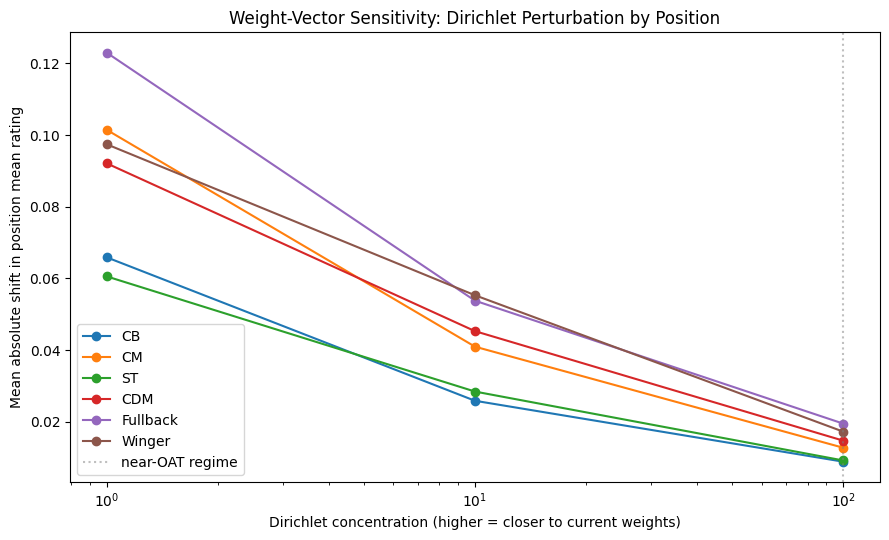

In [78]:
plt.figure(figsize=(9, 5.5))
for group in POSITIONS_TO_TEST.keys():
    sub = dirichlet_df[dirichlet_df['position'] == group].sort_values('concentration')
    plt.plot(sub['concentration'], sub['mean_abs_shift'], marker='o', label=group)

plt.xlabel("Dirichlet concentration (higher = closer to current weights)")
plt.ylabel("Mean absolute shift in position mean rating")
plt.title("Weight-Vector Sensitivity: Dirichlet Perturbation by Position")
plt.xscale('log')
plt.axvline(100, color='gray', linestyle=':', alpha=0.5, label='near-OAT regime')
plt.legend()
plt.tight_layout()
plt.show()

Lines converge toward zero as concentration increases, as expected - but
the ordering is preserved throughout: Fullback and Winger consistently most
sensitive, CB and ST consistently least. The log scale reveals that the
convergence is roughly linear in log-concentration space, suggesting no
threshold effects or regime changes - just smooth decay as the perturbed
vector gets closer to the baseline.

## Caveats

- **Goals only - assists were never in scope for the goal-coefficient test.**
- **A real bug (raw position code vs group label mismatch) was caught and
  fixed during development of the goal-coefficient test.**
- **CDM and Fullback's scale-comparability deficits are untouchable by the
  goal coefficient** - zero goals in this save.
- **The impact-scalar/smoothing comparison rests on the rating-spread-by-
  minutes-bucket statistic specifically.**
- **The tiered decomposition used a single multiplier (0.25).**
- **The mild smoothing interaction effect was noted but not formally
  decomposed.**
- **The 40-60 minute dip appeared independently across three statistics and
  remains uninvestigated.**
- **Z-score floor trigger rates were checked for possession_won/tackles
  only.**
- **The combined possession_won+tackles floor effect wasn't decomposed.**
- **CB and CM have no z-score floors** - structurally unreachable.
- **Mastery-bonus weight multipliers weren't swept separately.**
- **The mastery consistency check used a single arbitrary 5% target rarity.**
- **CDM, Winger, and ST have no clean-sheet bonus** - structurally
  unreachable.
- **Wingback excluded from the defender clean-sheet sweep.**
- **high_xg_threshold wasn't swept** - only 3 matches hit this tier.
- **The clean-sheet bonus refactor was implemented before testing.**
- **The sigmoid kink was retained after testing** - the blend systematically
  lowers ratings for 24.1% of performances with no upside.
- **The k_below sweep direction is counterintuitive** due to s_0
  re-derivation.
- **The supremacy lower_floor was not swept** - 0 of 155 matches reach
  -0.35 in this save.
- **All supremacy findings are specific to a dominant team context.**
- **Alpha-Drag sweeps are measured on 76 performances only (3.4%).**
- **The ALPHA_BASE × VERSATILITY_THRESHOLD interaction wasn't tested.**
- **Cosine similarity is a fixed lookup table, not swept.**
- **Dirichlet used 100 samples per (position, concentration) combination**
  - sufficient for a stable mean absolute shift estimate but not for
  tail-behaviour analysis. The Sobol variance decomposition described in
  the critical review (3.5) was not implemented - it would quantify
  parameter interaction effects OAT misses, but given the near-constant
  behaviour of the supremacy scalar in this save and the modest weight
  sensitivity confirmed here, the most interesting predicted interactions
  (supremacy × impact-scalar) are already partially explained by individual
  findings.

## Conclusions

**What this notebook covers:** ten sub-tests across the full pipeline -
goal coefficients, impact-scalar floor, Bayesian smoothing, z-score floors,
mastery bonus thresholds, clean-sheet bonuses, sigmoid k values, match
supremacy scalar, Alpha-Drag multi-position blending, and Dirichlet
weight-vector sensitivity. All hand-set parameters testable in this dataset
have been swept; all three methods described in the critical review's 3.5
(OAT, Dirichlet, Sobol) have been addressed, with Sobol explicitly deferred
as lower-priority given what the individual findings already explain.

### What's confirmed - goal coefficient
**Reaches only half the positions tested.** CDM and Fullback zero goals.
ST gap crosses zero at coefficient ~0.975, almost exactly CM's own 1.0.

### What's confirmed - impact-scalar floor vs Bayesian smoothing
**The named fix targets the wrong mechanism.** Smoothing's d is the actual
driver - 4x stronger cameo effect, diffused across all three tiers.

### What's confirmed - z-score floors
**Real, monotonic, small, saturating** (~0.02-0.03 points). CB and CM have
none - third structurally-unreachable finding.

### What's confirmed - mastery bonus thresholds
**Smallest full-dataset lever.** Two-cluster calibration inconsistency
confirmed. CB confirmed for the fourth time as most exposed to
possession_won/tackles. Threshold-sensitivity and absolute contribution
are genuinely distinct properties.

### What's confirmed - clean-sheet bonuses
**Largest single effect size** (0.39 points). Architectural issue found and
fixed. CDM/Winger/ST have none - fourth structurally-unreachable finding.

### What's confirmed - sigmoid k values
**Both branches live**, k_above ~4x more impactful. Kink at the mode of
the raw_score distribution. Smooth-transition alternative systematically
lowers 24.1% of ratings with no upside - retained as deliberate property.

### What's confirmed - match supremacy scalar
**Gamma and upper_cap live; lower_floor dead** - sixth structurally-
unreachable finding. Removing the scalar raises mean ratings 0.161 points
and increases xG-differential correlation Δρ +0.09 to +0.15.

### What's confirmed - Alpha-Drag
**All three constants real but whole-dataset impact bounded to ~0.004
points** by the 3.4% multi-position population. Parameters genuinely
balanced: drag down (ALPHA_BASE), reward up (VERSATILITY_BETA), threshold
controls access.

### What's confirmed - Dirichlet weight sensitivity
**Ratings are robust to weight perturbation in the realistic calibration
range, but position sensitivity has an important structural explanation.**
At concentration=100 (realistic calibration uncertainty), shifts are
0.009-0.020 points - smaller than any OAT lever effect. At concentration=1
(random weight vector), shifts reach 0.06-0.12 points - real but modest.
The position ranking (CB/ST least sensitive, Fullback most) is directly
explained: CB's dominant stats have compressed z-scores from Bayesian
smoothing (the same mechanism behind its reliability fragility), making
weight redistribution ineffective; ST's event-bonus anchor insulates it
from weight changes; Fullback has genuinely variable, unanchored signal
across a diverse weight structure. This largely settles the
PCA-vs-philosophy debate: within realistic calibration uncertainty, the
exact derivation method doesn't matter much.

### Recurring patterns across ten sub-tests
**Six structurally-inert lever/position combinations confirmed by direct
pre-analysis** - zero goals for CDM/Fullback, no floors for CB/CM, no
clean-sheet bonus for CDM/Winger/ST, no siege bonus anywhere in this save.

**"How often", "how much", and "how sensitive to retuning" are three
distinct questions**, consistently not answered by the same number.

**Several documented justifications don't survive direct testing:** the
impact-scalar floor was named as the cameo-compression fix (wrong
mechanism), the clean-sheet xG tier structure is near-redundant, and the
sigmoid blend looked neutral until tested.

**Save-specific context shapes many findings** - the dominant Valencia save
means the siege bonus, and several other levers, are untestable here.

### Three major actionable findings for the whitepaper
1. **The impact-scalar floor targets the wrong mechanism** - smooth
   recalibration should target smoothing's d thresholds instead.
2. **The clean-sheet bonus architecture was refined during this process** -
   minutes ramp added; the xG tier structure may warrant simplification.
3. **The mastery bonus family has a consistent two-cluster calibration
   inconsistency** - passes/dribbles uniformly loose, tackles/possession_won
   uniformly strict - worth deliberate recalibration if comparable rarity
   is the intent.

### 3.5 complete
All OAT sweeps run in pipeline order; Dirichlet sensitivity confirmed;
Sobol deferred as lower-priority given what individual findings explain.